# The US Politician Network — Explainer Notebook

**Computational Social Science · DTU**

This notebook documents every step of our pipeline: from data collection through preprocessing and analysis. It is the technical companion to our [website](https://keremozemre.github.io/Social_computational_science_Project/), which presents the same work for a non-technical reader.

The notebook is structured into 4 sections per the project brief:

1. **Motivation** — what dataset, why, and what we want the reader to take away
2. **Basic stats** — data cleaning, preprocessing, and the resulting dataset shape
3. **Tools, theory and analysis** — text and network methods, how they work, why we used them
4. **Discussion** — what went well, what is still missing

Heavy preprocessing cells (Wikidata SPARQL queries, the Wikipedia article fetch, the tokenisation pass) are wrapped in `if False:` so that running the notebook end-to-end does not re-trigger a 25-minute API job. The cached outputs (`politicians_with_communities.csv`, `politicians_full_text.csv`, `tokenized_wikipage.csv`) are loaded directly. Change `if False:` to `if True:` if you want to actually re-run a preprocessing stage.

# 1 — Motivation

## 1.1 What is your dataset?

Our dataset is a network of **6,138 American politicians** extracted from Wikipedia, plus the full plain-text article for each one of them. Concretely it has three layers:

- **Nodes** — 6,138 US politicians, each tagged with metadata from Wikidata: name, party, gender, position, state, education, career start/end dates, and a derived boolean for whether they attended a prestigious school.
- **Edges** — an undirected link between two politicians whenever their Wikipedia articles link to each other. This gives roughly 19,700 edges.
- **Text** — the full cleaned Wikipedia article for each politician, with boilerplate footer sections (References, See also, External links, Bibliography, etc.) stripped. About 56 million characters in total.

Sources:
- **Wikidata SPARQL endpoint** for the politician list and structured metadata.
- **MediaWiki `extracts` API** for the article text.
- **Wikipedia link graph** for the connections between politicians.

## 1.2 Why did you choose this dataset?

We chose to build on this dataset to get a better overview of how, especially in such a polarised political world, different political actors are represented and how they interact with each other. The motivation stems from Wikipedia increasingly becoming a primary information source for society. We want to investigate two things:

1. Whether Wikipedia offers substantive political information or dwells primarily on controversies (visible through word clouds of distinctive vocabulary).
2. Whether Wikipedia is genuinely neutral or contains systematic bias towards specific groups — and whether it reinforces or corrects political polarisation.

## 1.3 What was your goal for the end user's experience?

For the final takeaway, we want to give the user an understanding of how political interactions function by highlighting the network statistics and the communities that form. We also want to evaluate Wikipedia as a neutral and educational political source by analysing the sentiment and distinctive vocabulary of politician articles.

# 2 — Basic Stats: Understanding the Dataset

## 2.1 Data Collection — SPARQL + Wikipedia Link Walk

We use a five-phase approach to build the politician dataset.

**Filters applied in phases 1–3:**
- Must be a human (`wd:Q5`) with occupation politician (`wd:Q82955`)
- Must have held a US political office (`wdt:P17 wd:Q30`)
- Birth date ≤ 1990; no death date before 1980

**1. Seed Query** — Query Wikidata for the top 1,000 politicians ranked by number of Wikipedia language editions (a proxy for global importance), applying the filters above.

**2. Link Walking Seed Pages** — For each seed's English Wikipedia page, follow internal links to other US politicians satisfying the same filters. This extends the dataset to **3,776 politicians**.

**3. Link Walking Neighbour Pages** — Repeat step 2 on all neighbour pages from step 2. This extends the dataset to **6,625 politicians**.

**4. Feature Extraction** — For each politician, extract position held (with start/end dates), nationality, birth/death date, party, gender, education, state, and English Wikipedia URL via SPARQL.

**5. Manual Filtering** — Deduplicate entries by retaining only each politician's most prestigious position. Parties are simplified to **Democrat**, **Republican**, and **Other**. Career start and end are derived as the min/max dates across all entries, and any politician with a career end before 1980 is removed.

The final dataset **politicians_network_nodes_filtered.csv** contains **6,138 politicians** across 15 features.

In [ ]:
if False:  # change to True to re-run data collection
    import requests, time, json, re, pandas as pd
    from collections import defaultdict
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from datetime import datetime, timedelta
    from tqdm import tqdm
    import threading, random
    from bs4 import BeautifulSoup

### 1 — Shared session & constants

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    S = requests.Session()
    S.headers.update({"User-Agent": "PoliticiansNetwork/1.0 (kerem.ozemre@icloud.com)"})

    BASE_WIKI  = "https://en.wikipedia.org/w/api.php"
    SPARQL_URL = "https://query.wikidata.org/sparql"

    SKIP_PREFIXES = ("Special:", "Main_Page", "Wikipedia:", "Help:", "File:", "Portal:")


    def get_with_retry(url, params=None, session=S, max_retries=6):
        """GET with exponential backoff on 429 / 5xx."""
        for attempt in range(max_retries):
            try:
                r = session.get(url, params=params, timeout=30)
                if r.status_code == 429:
                    wait = 2 ** attempt + random.uniform(0.5, 1.5)
                    print(f"  Rate-limited, waiting {wait:.1f}s…")
                    time.sleep(wait)
                    continue
                r.raise_for_status()
                return r
            except requests.RequestException as e:
                if attempt == max_retries - 1:
                    raise RuntimeError(f"Failed after {max_retries} retries: {url}") from e
                time.sleep(2 ** attempt)
        raise RuntimeError(f"Failed after {max_retries} retries: {url}")


### 2 — SPARQL executor & helpers

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    SESSION = requests.Session()
    SESSION.headers.update({"User-Agent": "WikidataResearchBot/1.0 (kerem.ozemre@icloud.com)"})


    def run_sparql(query, retries=7, base_sleep=2.0):
        for attempt in range(retries):
            try:
                r = SESSION.post(
                    SPARQL_URL,
                    data={"query": query},
                    headers={"Accept": "application/json",
                             "User-Agent": "WikidataResearchBot/1.0"},
                    timeout=120,
                )
                if r.status_code == 429:
                    wait = base_sleep * (2 ** attempt)
                    print(f"  Wikidata 429 — waiting {wait:.0f}s (attempt {attempt+1})")
                    time.sleep(wait)
                    continue
                if r.status_code in (500, 502, 503, 504):   # ← added 504
                    wait = base_sleep * (2 ** attempt)
                    print(f"  Wikidata {r.status_code} — waiting {wait:.0f}s (attempt {attempt+1})")
                    time.sleep(wait)
                    continue
                r.raise_for_status()
                return r.json()
            except requests.exceptions.Timeout:
                wait = base_sleep * (2 ** attempt)
                print(f"  Wikidata timeout (attempt {attempt+1}/{retries}) — waiting {wait:.0f}s")
                time.sleep(wait)
            except Exception as e:
                if attempt == retries - 1:
                    raise RuntimeError(f"SPARQL failed: {e}")
                time.sleep(base_sleep * (2 ** attempt))
        raise RuntimeError(f"SPARQL failed after {retries} retries")


    def chunked(lst, size):
        for i in range(0, len(lst), size):
            yield lst[i:i + size]


    def parse_wikidata_date(raw):
        """Extract YYYY-MM-DD from a Wikidata timestamp string."""
        if not raw:
            return None
        m = re.match(r"[+-]?(\d{4}-\d{2}-\d{2})", raw)
        return m.group(1) if m else None


    def extract_qid(uri):
        return uri.split("/")[-1]

### 3 — Popularity-ranked seed fetcher

Queries Wikidata for politicians ordered by **sitelink count** — the number of Wikipedia
language editions that cover them. This is the best available proxy for global notability
without hitting the pageviews API.

Filters: human (`P31=Q5`), politician (`P106=Q82955`), born ≤ 1970,
alive or died ≥ 1980.  
Remove `wdt:P27 wd:Q30` to go global instead of US-only.

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    def make_seed_query(limit=500, offset=0):
        return f"""
        SELECT DISTINCT ?person (COUNT(?sitelink) AS ?links) WHERE {{
          ?person wdt:P31 wd:Q5 ;       # person
                  wdt:P106 wd:Q82955 . # occupation: politician

          ?person p:P39 ?stmt .         # held position (P39) statement
          ?stmt ps:P39 ?office .        
          ?office wdt:P17 wd:Q30 .          # office belongs to the United States

          OPTIONAL {{ ?person wdt:P569 ?birth. }} # date of birth
          OPTIONAL {{ ?person wdt:P570 ?death. }} # date of death  

          FILTER(
            BOUND(?birth) && YEAR(?birth) <= 1990
            && ( !BOUND(?death) || YEAR(?death) >= 1980 )
          )

          ?sitelink schema:about ?person .
        }}
        GROUP BY ?person
        ORDER BY DESC(?links) # most linked = most cross-wiki-covered
        LIMIT {limit}
        OFFSET {offset}
        """


    def get_popular_politician_ids(max_seeds=800, page_size=500):
        """
        Return QID URI list for the most cross-wiki-covered politicians,
        paginating until max_seeds is reached or results are exhausted.
        page_size kept at 500 — GROUP BY + ORDER BY queries time out above ~500.
        """
        ids    = []
        offset = 0

        while len(ids) < max_seeds:
            query    = make_seed_query(limit=page_size, offset=offset)
            data     = run_sparql(query)
            bindings = data["results"]["bindings"]
            if not bindings:
                break
            batch = [b["person"]["value"] for b in bindings]
            ids.extend(batch)
            print(f"  Collected {len(ids)} seeds…")
            offset += page_size
            time.sleep(2)   # GROUP BY queries are heavier — be polite

        return ids[:max_seeds]


### 4 — Label fetcher

Resolves QIDs - English Wikipedia article titles.
The link-walker needs these titles to look up pages.
Also used to refresh titles for neighbor nodes discovered in expansion passes.

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    def fetch_labels(qids, batch_size=400):
        """
        Fetch English Wikipedia titles for a list of QIDs.
        Returns {wikipedia_title: qid} for QIDs that have an enwiki article.
        """
        name_to_qid = {}

        for chunk in tqdm(list(chunked(qids, batch_size)), desc="Fetching labels"):
            values = " ".join(f"wd:{q}" for q in chunk)
            query  = f"""
            SELECT ?person ?article WHERE {{
              VALUES ?person {{ {values} }}
              ?article schema:about ?person ;
                       schema:isPartOf <https://en.wikipedia.org/> .
            }}
            """
            data = run_sparql(query)
            for b in data["results"]["bindings"]:
                qid   = b["person"]["value"].split("/")[-1]
                title = (b["article"]["value"]
                         .replace("https://en.wikipedia.org/wiki/", "")
                         .replace("_", " "))
                name_to_qid[title] = qid
            time.sleep(1)

        print(f"  {len(name_to_qid)} QIDs have an English Wikipedia article")
        return name_to_qid


### 5 — Wikipedia link-walker (degree and connections)

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    # ── Rate-limit governor ────────────────────────────────────────────────────────
    _WIKI_SEM      = threading.Semaphore(4)
    _BACKOFF_LOCK  = threading.Lock()
    _BACKOFF_UNTIL = 0.0

    def _wait_for_backoff():
        with _BACKOFF_LOCK:
            target = _BACKOFF_UNTIL
        remaining = target - time.monotonic()
        if remaining > 0:
            time.sleep(remaining)

    def _set_backoff(seconds):
        global _BACKOFF_UNTIL
        with _BACKOFF_LOCK:
            _BACKOFF_UNTIL = max(_BACKOFF_UNTIL, time.monotonic() + seconds)


    # ── Fetch links from article body only (no navboxes/tables) ───────────────────
    def get_page_links_body_only(title):
        """
        Fetch only links that appear in article body prose.
        Strips navboxes, delegation tables, infoboxes — these are the source
        of the CA-delegation cluster artifact (e.g. every CA rep links to every
        other CA rep via the 'California delegation' navbox on their page).
        """
        session = requests.Session()
        session.headers.update({"User-Agent": "PoliticiansNetwork/1.0 (kerem.ozemre@icloud.com)"})

        params = {
            "action":    "parse",
            "page":      title,
            "prop":      "text",
            "format":    "json",
            "redirects": 1,
        }

        for attempt in range(6):
            try:
                r = get_with_retry("https://en.wikipedia.org/w/api.php",
                                   params=params, session=session)
                html = r.json().get("parse", {}).get("text", {}).get("*", "")
                break
            except Exception as e:
                if attempt == 5:
                    return []
                time.sleep(2 ** attempt)

        soup = BeautifulSoup(html, "html.parser")

        # Remove navboxes, tables, infoboxes, succession boxes, references
        for tag in soup.find_all(class_=[
            "navbox", "navbox-inner", "navbox-subgroup", "navbox-list",
            "wikitable", "infobox", "succession-box",
            "mw-references-wrap", "reflist", "portal",
            "noprint", "side-box", "sistersitebox",
        ]):
            tag.decompose()

        # Remove all <table> tags (catches delegation tables not covered above)
        for tag in soup.find_all("table"):
            tag.decompose()

        # Remove reference/external sections
        for section_id in ["References", "External_links", "See_also", "Further_reading"]:
            tag = soup.find(id=section_id)
            if tag:
                # Remove everything from this heading onward
                for sibling in tag.find_all_next():
                    sibling.decompose()
                tag.decompose()

        # Collect links only from <p> paragraph tags
        links = []
        for p in soup.find_all("p"):
            for a in p.find_all("a", href=True):
                href = a["href"]
                if href.startswith("/wiki/") and ":" not in href:
                    links.append(href[6:].replace("_", " "))

        return links


    # ── Thread-safe caches ─────────────────────────────────────────────────────────
    _title_lock = threading.Lock()
    _qid_lock   = threading.Lock()

    def resolve_titles_to_qids_cached(titles, cache, batch_size=50):
        with _title_lock:
            uncached = [t for t in titles if t not in cache]
        for i in range(0, len(uncached), batch_size):
            batch  = uncached[i:i + batch_size]
            params = {
                "action": "query", "titles": "|".join(batch),
                "prop": "pageprops", "ppprop": "wikibase_item", "format": "json",
            }
            r     = get_with_retry(BASE_WIKI, params=params)
            pages = r.json()["query"]["pages"]
            norm  = {n["from"]: n["to"] for n in r.json()["query"].get("normalized", [])}
            result = {}
            for page in pages.values():
                qid    = page.get("pageprops", {}).get("wikibase_item")
                ptitle = page.get("title", "")
                result[ptitle] = qid
            for orig, norm_title in norm.items():
                if norm_title in result:
                    result[orig] = result[norm_title]
            with _title_lock:
                cache.update(result)
            time.sleep(0.1)
        with _title_lock:
            return {t: cache.get(t) for t in titles}


    def filter_politician_qids_cached(qids, cache, batch_size=200):
        with _qid_lock:
            unchecked = [q for q in qids if q not in cache["seen"]]
        for i in range(0, len(unchecked), batch_size):
            batch  = unchecked[i:i + batch_size]
            values = " ".join(f"wd:{q}" for q in batch)
            query  = f"""
            SELECT ?person WHERE {{
              VALUES ?person {{ {values} }}
              ?person wdt:P106 wd:Q82955 .

              # Must have held a US office
              ?person p:P39 ?stmt .
              ?stmt ps:P39 ?office .
              ?office wdt:P17 wd:Q30 .

              # Same date filter as seeds
              OPTIONAL {{ ?person wdt:P569 ?birth. }}
              OPTIONAL {{ ?person wdt:P570 ?death. }}
              FILTER(
                BOUND(?birth) && YEAR(?birth) <= 1990
                && ( !BOUND(?death) || YEAR(?death) >= 1980 )
              )
            }}
            """
            data  = run_sparql(query)
            found = [item["person"]["value"].split("/")[-1]
                     for item in data["results"]["bindings"]]
            with _qid_lock:
                cache["politicians"].update(found)
                cache["seen"].update(batch)
            time.sleep(0.5)
        with _qid_lock:
            return cache["politicians"]


    # ── Serial walker with adaptive throttle ──────────────────────────────────────
    def compute_politician_degrees(name_to_qid, title_qid_cache=None, politician_cache=None):
        """
        Walk Wikipedia pages for each politician in name_to_qid.
        Returns (degrees, neighbours) dicts keyed by QID.
        Caches are shared across calls so repeated QIDs are only looked up once.
        """
        if title_qid_cache is None:
            title_qid_cache = {}
        if politician_cache is None:
            politician_cache = {"seen": set(), "politicians": set()}

        degrees   = {}
        neighbors = {}
        delay     = 0.5   # slightly higher base delay since parse API is heavier than links API

        for idx, (title, qid) in enumerate(tqdm(name_to_qid.items(), desc="Walking pages"), 1):
            linked_titles = []
            for attempt in range(6):
                try:
                    linked_titles = get_page_links_body_only(title)
                    delay = max(0.3, delay * 0.97)
                    break
                except Exception as e:
                    if "429" in str(e):
                        delay = min(30, delay * 2)
                        print(f"  429 on '{title}' — slowing to {delay:.1f}s")
                        time.sleep(delay)
                    elif attempt == 5:
                        print(f"  Giving up on '{title}': {e}")
                        break
                    else:
                        time.sleep(2 ** attempt)

            if not linked_titles:
                degrees[qid]   = 0
                neighbors[qid] = []
            else:
                t2q            = resolve_titles_to_qids_cached(linked_titles, title_qid_cache)
                linked_qids    = [q for q in t2q.values() if q]
                pol_set        = filter_politician_qids_cached(linked_qids, politician_cache) if linked_qids else set()
                pol_qids       = [q for q in linked_qids if q in pol_set]
                degrees[qid]   = len(pol_qids)
                neighbors[qid] = pol_qids

            time.sleep(delay)

            if idx % 50 == 0:
                print(f"  [{idx}/{len(name_to_qid)}] delay={delay:.2f}s | "
                      f"title cache={len(title_qid_cache)} | "
                      f"qid cache={len(politician_cache['seen'])}")

        return degrees,neighbors


### 6 — Information and Feature Fetcher

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    def make_details_query(person_ids):
        values = " ".join(f"wd:{p.split('/')[-1]}" for p in person_ids)
        return f"""
        SELECT
          ?person ?personLabel ?positionLabel
          ?start ?end ?natLabel ?birth ?death
          ?partyLabel ?genderLabel ?educationLabel ?stateLabel ?article
        WHERE {{
          VALUES ?person {{ {values} }}

          ?person p:P39 ?statement .
          ?statement ps:P39 ?position .
          OPTIONAL {{ ?statement pq:P580 ?start. }}
          OPTIONAL {{ ?statement pq:P582 ?end. }}

          OPTIONAL {{ ?person wdt:P27 ?nat. }}
          OPTIONAL {{ ?person wdt:P569 ?birth. }}
          OPTIONAL {{ ?person wdt:P570 ?death. }}
          OPTIONAL {{ ?person wdt:P102 ?party. }}
          OPTIONAL {{ ?person wdt:P21 ?gender. }}
          OPTIONAL {{ ?person wdt:P69 ?education. }}
          OPTIONAL {{ ?position wdt:P131 ?state. }}
          OPTIONAL {{
            ?article schema:about ?person ;
                     schema:isPartOf <https://en.wikipedia.org/> .
          }}

          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
        }}
        """


    def fetch_details(person_ids, batch_size=50):
        rows = []
        for i, chunk in enumerate(chunked(person_ids, batch_size), 1):
            print(f"  Details batch {i}/{-(-len(person_ids)//batch_size)} ({len(chunk)} people)")
            data = run_sparql(make_details_query(chunk))
            for item in data["results"]["bindings"]:
                rows.append({
                    "wikidata":      extract_qid(item["person"]["value"]),
                    "name":          item.get("personLabel",   {}).get("value"),
                    "position":      item.get("positionLabel", {}).get("value"),
                    "start":         parse_wikidata_date(item.get("start",  {}).get("value")),
                    "end":           parse_wikidata_date(item.get("end",    {}).get("value")),
                    "nationality":   item.get("natLabel",      {}).get("value"),
                    "birth_date":    parse_wikidata_date(item.get("birth",  {}).get("value")),
                    "death_date":    parse_wikidata_date(item.get("death",  {}).get("value")),
                    "party":         item.get("partyLabel",    {}).get("value"),
                    "gender":        item.get("genderLabel",   {}).get("value"),
                    "education":     item.get("educationLabel",{}).get("value"),
                    "state":         item.get("stateLabel",    {}).get("value"),
                    "wikipedia_url": item.get("article",       {}).get("value"),
                })
            time.sleep(1.5)
        return rows


### 7 — Manual Filtering

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    POSITION_RANK = {
        "President of the United States": 1,
        "Vice President of the United States": 2,
        "Secretary of State": 3,
        "Secretary of Defense": 4,
        "Attorney General of the United States": 5,
        "Secretary of the Treasury": 6,
        "White House Chief of Staff": 7,
        "United States Senator": 8,
        "Speaker of the House of Representatives": 9,
        "House Majority Leader": 10,
        "Senate Majority Leader": 10,
        "United States Representative": 11,
        "Governor": 12,
        "Ambassador": 13,
        "Lieutenant Governor": 14,
        "State Senator": 15,
        "State Representative": 16,
        "Mayor": 17,
    }

    def position_priority(pos):
        if pos is None:
            return 999
        if pos in POSITION_RANK:
            return POSITION_RANK[pos]
        for key, rank in POSITION_RANK.items():
            if key.lower() in pos.lower():
                return rank
        return 998
    def simplify_party(p):
        if pd.isna(p):
            return "Other"

        p_lower = p.lower()

        # Major parties
        if "democratic" in p_lower:
            return "Democrat"
        if "republican" in p_lower:
            return "Republican" 
        return "Other"

    # Positions that are clearly not elected offices
    ADVISOR_POSITIONS = {
        "Senior Advisor to the President of the United States",
        "White House Chief Strategist",
        "Assistant to the President",
        "Counselor to the President",
        "Senior Counselor",
        "White House Press Secretary",
        "White House Communications Director",
        "Director of the Office of Management and Budget",
    }




    def dedup_df(df):
        """
        Per unique wikidata QID:
          - position  → most prestigious title (lowest POSITION_RANK score)
          - start     → earliest start date across all positions
          - end       → latest end date across all positions
          - all other columns (party, gender, education, etc.) → from the most prestigious row
        """
        df = df.copy()
        df["position_rank"] = df["position"].apply(position_priority)

        # ── Most prestigious row per person (for title + all metadata) ─────────────
        best = (df.sort_values("position_rank")
                  .drop_duplicates(subset=["wikidata"], keep="first")
                  .set_index("wikidata"))

        # ── Earliest start date per person ────────────────────────────────────────
        earliest_start = (df[df["start"].notna()]
                          .sort_values("start")
                          .drop_duplicates(subset=["wikidata"], keep="first")
                          .set_index("wikidata")["start"])

        # ── Latest end date per person ─────────────────────────────────────────────
        # Treat NaN end as still in office — represented as None, not overwritten
        latest_end = (df[df["end"].notna()]
                      .sort_values("end", ascending=False)
                      .drop_duplicates(subset=["wikidata"], keep="first")
                      .set_index("wikidata")["end"])

        # ── Assemble ───────────────────────────────────────────────────────────────
        best["career_start"] = best.index.map(earliest_start)
        best["career_end"]   = best.index.map(latest_end)

        # If someone has no end date at all, career_end stays None (still in office)
        # If someone has no start date at all, career_start stays None

        result = best.drop(columns=["start", "end", "position_rank"]).reset_index()

        

        print(f"  {len(result)} unique politicians after dedup")
        print(f"  career_start filled: {result['career_start'].notna().sum()}")
        print(f"    career_end filled: {result['career_end'].notna().sum()} "
              f"({result['career_end'].isna().sum()} still in office or unknown)")
        return result

### 8 — Pipeline

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    def run_pipeline(max_seeds=800, expand_neighbors=False):
        # ── Phase 1: popularity-ranked seeds ──────────────────────────────────────
        print("=" * 60)
        print("Phase 1 — Fetching popularity-ranked seed IDs…")
        seed_uris = get_popular_politician_ids(max_seeds=max_seeds)
        seed_qids = {extract_qid(u) for u in seed_uris}
        print(f"  Unique seeds: {len(seed_qids)}")

        print("\nFetching Wikipedia titles for seeds…")
        seed_titles = fetch_labels(list(seed_qids))
        print(f"  Seeds with enwiki article: {len(seed_titles)}")

        # Shared caches — reused across both expansion passes
        title_qid_cache  = {}
        politician_cache = {"seen": set(), "politicians": set()}

        # ── Phase 2: link-walk seeds ───────────────────────────────────────────────
        print("\n" + "=" * 60)
        print("Phase 2 — Link-walking seed pages…")
        degrees, neighbours = compute_politician_degrees(
            seed_titles, title_qid_cache, politician_cache
        )

        neighbor_qids_1 = {q for conns in neighbours.values() for q in conns} - seed_qids
        all_qids        = seed_qids | neighbor_qids_1
        print(f"  Seeds              : {len(seed_qids)}")
        print(f"  New from pass 1    : {len(neighbor_qids_1)}")
        print(f"  Total after pass 1 : {len(all_qids)}")

        # ── Phase 3: optional second expansion pass ────────────────────────────────
        if expand_neighbors and neighbor_qids_1:
            print("\n" + "=" * 60)
            print("Phase 3 — Link-walking neighbor pages…")
            neighbor_titles = fetch_labels(list(neighbor_qids_1))
            degrees_2, neighbours_2 = compute_politician_degrees(
                neighbor_titles, title_qid_cache, politician_cache
            )

            neighbor_qids_2 = {q for conns in neighbours_2.values() for q in conns} - all_qids
            all_qids       |= neighbor_qids_2
            print(f"  New from pass 2    : {len(neighbor_qids_2)}")
            print(f"  Total after pass 2 : {len(all_qids)}")

            degrees.update(degrees_2)
            neighbours.update(neighbours_2)

        # ── Link-walk the non-seed neighbors too ──────────────────────────────────
        # Seeds already have degrees/neighbours from the walk above.
        # Non-seed nodes were only *discovered* as neighbors — we haven't walked
        # their pages yet, so we do that now to get their connections too.
        non_seed_qids   = all_qids - seed_qids
        non_seed_titles = fetch_labels(list(non_seed_qids))
        print(f"\nLink-walking {len(non_seed_titles)} non-seed pages for their connections…")
        degrees_ns, neighbours_ns = compute_politician_degrees(
            non_seed_titles, title_qid_cache, politician_cache
        )
        # Only add — don't overwrite seeds that were already walked
        for qid, deg in degrees_ns.items():
            if qid not in degrees:
                degrees[qid]   = deg
                neighbours[qid] = neighbours_ns[qid]

        # ── Phase 4: fetch features for everyone ──────────────────────────────────
        print("\n" + "=" * 60)
        print(f"Phase 4 — Fetching features for all {len(all_qids)} politicians…")
        all_uris = [f"http://www.wikidata.org/entity/{q}" for q in all_qids]
        rows     = fetch_details(all_uris)

        df = pd.DataFrame(rows)
        df = dedup_df(df)
        df["connections"] = df["wikidata"].map(neighbours).apply(
            lambda x: x if isinstance(x, list) else []
        )
        df["is_seed"] = df["wikidata"].isin(seed_qids)

        # ── Save edges to JSON ─────────────────────────────────────────────────────
        import json
        node_set     = set(df["wikidata"])
        clean_edges  = {
            qid: [n for n in conns if n in node_set]
            for qid, conns in neighbours.items()
            if qid in node_set
        }
        print(f"Saved → politician_edges.json  "
              f"({len(clean_edges)} nodes, "
              f"{sum(len(v) for v in clean_edges.values())} total edge entries)")

        # ── Save node CSV ──────────────────────────────────────────────────────────
        df.to_csv("politicians_network_nodes.csv", index=False)
        print(f"Saved → politicians_network_nodes.csv  ({len(df)} rows)")

        n_seeds = df["is_seed"].sum()
        print(f"\n{'=' * 60}")
        print(f"Pipeline complete.")
        print(f"  Seed nodes     : {n_seeds}")
        print(f"  Expanded nodes : {len(df) - n_seeds}")
        print(f"  Total nodes    : {len(df)}")
        return df


    df = run_pipeline(max_seeds=1000, expand_neighbors=True)


### 9 — Save

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    if not df.empty:
        print(f"Shape: {df.shape}")
        print(df.head(20).to_string())
    else:
        print("Nothing to save — DataFrame is empty.")

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    df["party"] = df["party"].apply(simplify_party)

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    career_end_dt = pd.to_datetime(df["career_end"], errors="coerce")

    # Keep if: career_end is NaT (still active / unknown) OR career ended >= 1980
    mask = career_end_dt.isna() | (career_end_dt >= pd.Timestamp("1980-01-01"))

    df = df[mask].reset_index(drop=True)

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    df.to_csv("politicians_network_nodes_filtered.csv", index=False)

## 2.2 Full Wikipedia Text Extraction

For each politician we fetch their full plain-text Wikipedia article via the MediaWiki `extracts` API with `explaintext=1`. We preserve `== Section ==` markers and strip boilerplate footer sections: References, Notes, Footnotes, Citations, See also, External links, Bibliography, Sources, Further reading, Works, Publications.

**Why strip footers but keep all other sections?** Keeping the full article body (Early life, Political career, Personal life, Controversies etc.) gives the richest signal for both TF-IDF and sentiment. Footers are structural metadata, not editorial content — including them would pollute the text with reference numbers and link text.

Each article is cached to `wiki_full_text_cache/<wikidata>.json` so the script is resumable on crashes.

Extracts the full plain-text Wikipedia article for every politician in `politicians_with_communities.csv`.

Output: `politicians_full_text.csv` with the original metadata columns plus one text column `body_text` containing the full cleaned article (intro + all kept sections, with `== Section ==` markers preserved). Boilerplate footer sections (References, See also, External links, Bibliography, Sources, Further reading, Notes, Footnotes, Citations, Works, Publications) are dropped together with their subsections.

Final columns:
`wikidata, name, position, start, end, nationality, birth_date, death_date, party, party_simple, gender, education, state, degree, wikipedia_url, body_text`

In [ ]:
if False:  # change to True to re-run text extraction
    import os, re, json, time, glob
    from urllib.parse import unquote
    import requests, pandas as pd
    from tqdm import tqdm

    API_URL        = 'https://en.wikipedia.org/w/api.php'
    CACHE_DIR      = 'wiki_full_text_cache'
    INPUT_CSV      = 'politicians_with_communities.csv'
    OUTPUT_CSV     = 'politicians_full_text.csv'
    REQUEST_DELAY  = 0.15

    os.makedirs(CACHE_DIR, exist_ok=True)
    session = requests.Session()
    session.headers.update({'User-Agent': 'PoliticiansNetwork/1.0'})

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    df_nodes = pd.read_csv(INPUT_CSV)
    print(f'Loaded {len(df_nodes)} politicians from {INPUT_CSV}')
    print('Columns:', list(df_nodes.columns))
    df_nodes.head(3)

### API helper

Uses `prop=extracts` with `explaintext=1` (clean plain text, no HTML/refs/infoboxes) and `exsectionformat=wiki` (preserves `== Section ==` markers). One title per call so we get full text (batching forces intro-only).

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    def title_from_url(url):
        if not isinstance(url, str) or '/wiki/' not in url:
            return ''
        return unquote(url.rstrip('/').split('/wiki/')[-1])

    def fetch_full_article(title):
        if not title:
            return ''
        params = {
            'action': 'query',
            'format': 'json',
            'titles': title,
            'prop': 'extracts',
            'explaintext': 1,
            'exsectionformat': 'wiki',
            'redirects': 1,
        }
        r = session.get(API_URL, params=params, timeout=REQUEST_TIMEOUT_S)
        r.raise_for_status()
        pages = r.json().get('query', {}).get('pages', {})
        if not pages:
            return ''
        page = next(iter(pages.values()))
        return page.get('extract', '') or ''

### Boilerplate filter

`clean_full_text` removes top-level sections (and their subsections) matching: References, Notes, Footnotes, Citations, See also, External links, Bibliography, Sources, Further reading, Works, Selected works, Publications, Selected publications. Returns the full cleaned article as one string with `== Section ==` markers preserved.

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    SECTION_HEADER_RE = re.compile(r'^(=+)\s*(.+?)\s*\1\s*$', re.MULTILINE)

    BOILERPLATE_PATTERNS = [
        'references', 'notes', 'footnotes', 'citations',
        'see also', 'external links',
        'bibliography', 'sources', 'further reading',
        'works', 'selected works', 'publications', 'selected publications',
    ]

    def is_boilerplate(section_title):
        t = section_title.strip().lower().rstrip(':')
        if t in BOILERPLATE_PATTERNS:
            return True
        for p in BOILERPLATE_PATTERNS:
            if t == p or t.startswith(p + ' ') or t.endswith(' ' + p):
                return True
        return False

    def clean_full_text(full_text):
        """Return the full article as one string with boilerplate sections removed.
        Keeps the intro plus all non-boilerplate sections, with `== Section ==` headers preserved."""
        if not full_text:
            return ''
        matches = list(SECTION_HEADER_RE.finditer(full_text))
        if not matches:
            return full_text.strip()
        intro = full_text[:matches[0].start()].strip()
        sections = []
        for i, m in enumerate(matches):
            level = len(m.group(1))
            title = m.group(2).strip()
            s = m.end()
            e = matches[i+1].start() if i+1 < len(matches) else len(full_text)
            sections.append((level, title, full_text[s:e].strip()))
        cleaned_parts = []
        if intro:
            cleaned_parts.append(intro)
        skipping = False
        for level, title, body in sections:
            if level == 2:
                skipping = is_boilerplate(title)
            if skipping:
                continue
            marker = '=' * level
            cleaned_parts.append(f'{marker} {title} {marker}')
            if body:
                cleaned_parts.append(body)
        return '\n\n'.join(cleaned_parts).strip()

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    _demo = (
        'Barack Obama is a politician.\n\n'
        '== Early life and education ==\n\nBorn in Honolulu.\n\n'
        '=== Childhood ===\n\nHawaii.\n\n'
        '== Political career ==\n\nServed as senator.\n\n'
        '== References ==\n\n[1] cite\n\n'
        '=== Sub-ref ===\n\nshould drop\n\n'
        '== External links ==\n\nlinks\n'
    )
    print(clean_full_text(_demo))

### Cache helpers — successful entries reused, errored entries retried

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    def cache_path(wikidata_id):
        return os.path.join(CACHE_DIR, f'{wikidata_id}.json')

    def load_cached(wikidata_id):
        p = cache_path(wikidata_id)
        if os.path.exists(p):
            try:
                with open(p, 'r', encoding='utf-8') as f:
                    return json.load(f)
            except Exception:
                return None
        return None

    def save_cached(wikidata_id, payload):
        with open(cache_path(wikidata_id), 'w', encoding='utf-8') as f:
            json.dump(payload, f, ensure_ascii=False)

    def is_usable_cache(payload):
        return payload is not None and not payload.get('error')

    def get_or_fetch(wikidata_id, title):
        cached = load_cached(wikidata_id)
        if is_usable_cache(cached):
            return cached, True
        try:
            text = fetch_full_article(title)
            payload = {'wikidata': wikidata_id, 'title': title, 'raw_text': text, 'error': None}
        except Exception as e:
            payload = {'wikidata': wikidata_id, 'title': title, 'raw_text': '', 'error': str(e)}
        save_cached(wikidata_id, payload)
        return payload, False

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    _existing = glob.glob(os.path.join(CACHE_DIR, '*.json'))
    _err = 0
    _ok = 0
    for f in _existing:
        try:
            d = json.load(open(f, encoding='utf-8'))
            if d.get('error'):
                _err += 1
            else:
                _ok += 1
        except Exception:
            pass
    print(f'Cache files: {len(_existing)} ({_ok} OK, {_err} errored — will be retried)')

### Main extraction loop

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    rows = []
    errors = []
    fetched_from_api = 0
    loaded_from_cache = 0

    subset = df_nodes[df_nodes['wikipedia_url'].notna() & (df_nodes['wikipedia_url'] != '')].copy()
    print(f'Processing {len(subset)} politicians.')

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc='Fetching full articles'):
        wikidata_id = row['wikidata']
        title = title_from_url(row['wikipedia_url'])
        payload, was_cached = get_or_fetch(wikidata_id, title)
        if was_cached:
            loaded_from_cache += 1
        else:
            fetched_from_api += 1
            time.sleep(REQUEST_DELAY_S)
        if payload.get('error'):
            errors.append((wikidata_id, title, payload['error']))
        body_text = clean_full_text(payload.get('raw_text', ''))
        rows.append({'wikidata': wikidata_id, 'body_text': body_text})

    print(f'\nDone. From cache: {loaded_from_cache} | from API: {fetched_from_api} | errors: {len(errors)}')
    if errors:
        print('First 10 errors:')
        for e in errors[:10]:
            print(' ', e[0], e[1], '->', e[2][:120])

### Build wide CSV — metadata + body_text

Renames `career_start` - `start` and `career_end` - `end`.

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    df_text = pd.DataFrame(rows)
    df_meta = df_nodes.rename(columns={'career_start': 'start', 'career_end': 'end'}).copy()
    df_out = df_meta.merge(df_text, on='wikidata', how='left')


    df_out.to_csv(OUTPUT_CSV, index=False)
    print(f'Saved {len(df_out)} rows to {OUTPUT_CSV}')
    print('Columns:', list(df_out.columns))
    df_out.head(3)

### Sanity checks

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    body_len = df_out['body_text'].fillna('').astype(str).str.len()

    print('=== Coverage ===')
    print(f'Rows total              : {len(df_out)}')
    print(f'Empty body_text         : {(body_len == 0).sum()}')
    print()
    print('=== body_text length distribution (chars) ===')
    print(body_len.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(0))
    print()
    print('=== Top 5 longest ===')
    tmp = df_out.assign(_len=body_len)
    print(tmp.nlargest(5, '_len')[['name', '_len']].to_string(index=False))
    print()
    print('=== 5 shortest non-empty ===')
    ne = tmp[tmp['_len'] > 0]
    print(ne.nsmallest(5, '_len')[['name', '_len']].to_string(index=False))
    print()
    print('=== Spot check: did Obama, Biden, Trump come back? ===')
    for q in ['Q76', 'Q6279', 'Q22686']:
        sub = df_out[df_out['wikidata'] == q]
        if len(sub):
            r = sub.iloc[0]
            print(f"  {r['name']:20s} body_len={len(str(r['body_text'])):>7d}")

## 2.3 Tokenisation

Our text-preprocessing pipeline has two passes:

**Pass 1 — Intermediate tokeniser (for bigram discovery):**
1. Clean text while **preserving capitalisation** (important for POS tagging)
2. POS-tag each sentence with NLTK's averaged perceptron tagger
3. Keep broad POS set including proper nouns (NNP/NNPS) so collocations like *supreme_court* and *civil_right* are discovered correctly
4. Lowercase, remove stopwords, lemmatise with WordNet

**Pass 2 — Final tokeniser:**
1. Same cleaning and POS-tagging on original-case text
2. Keep only **common nouns (NN/NNS) and verbs (VB*)** — proper nouns are explicitly dropped
3. Merge known collocations using NLTK's `MWETokenizer`
4. Lemmatise single-word tokens using their POS tag; leave collocations as-is

**Why lemmatise instead of stem?** Porter stemming aggressively truncates words (e.g. "policies" → "polici") producing unreadable tokens. WordNet lemmatisation maps to actual dictionary forms ("policies" → "policy") which are interpretable in word clouds and TF-IDF outputs.

**Why drop proper nouns in the final pass?** Tagging on original-case text allows the tagger to correctly identify "Obama" as NNP and "policy" as NN. Filtering NNP/NNPS removes person names, place names, and organisation names that otherwise dominate community word clouds without conveying thematic content.

**Bigram discovery:** We test each candidate bigram using a χ² test of independence. A bigram is kept as a collocation if p < 0.001 and count > 50. This threshold recovers meaningful multi-word concepts (e.g. *environmental_protection*, *foreign_policy*) while rejecting accidental co-occurrences.

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    import nltk
    import pandas as pd
    import ast

    df = pd.read_csv('/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/social compute/Social_computational_science_Project/politicians_full_text.csv')

### Alternative 1 - Porter Stemmer

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    import nltk
    import re
    nltk.download('punkt_tab')
    from nltk.tokenize import sent_tokenize
    from nltk.stem import PorterStemmer
    from nltk.corpus import stopwords
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    def tokenize(text):
        text = text.lower()
        
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        
        words = text.split()
        filtered_words = [word for word in words if word not in stop_words]
        stems = [stemmer.stem(word) for word in filtered_words]
        
        
        return stems

    df["tokens"] = df["body_text"].dropna().apply(tokenize)

### Alternative 2 - WordNetLemmatizer

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    import re
    import math
    import numpy as np
    from collections import Counter
    from scipy.stats import chi2
    from nltk.stem import WordNetLemmatizer
    from nltk.corpus import stopwords, wordnet
    import nltk

    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    def get_wordnet_pos(word):
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'R': wordnet.ADV}
        return tag_map.get(tag, wordnet.NOUN)

    def tokenize_lemmatized(abstract):
        """Clean → remove stopwords → lemmatize. Used for bigram discovery."""
        if not isinstance(abstract, str):
            return []
        text = abstract.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        words = [w for w in text.split() if w not in stop_words]
        return [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words]

    df["tokens_lemmatized"] = df["body_text"].apply(tokenize_lemmatized)
    df[["tokens", "tokens_lemmatized"]].head()

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    from nltk.probability import FreqDist

    all_tokens = df["tokens_lemmatized"].explode().tolist()

    fq = FreqDist(all_tokens)
    fq.most_common(10)

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    clean_tokens = [t for t in all_tokens if t is not None and not (isinstance(t, float) and math.isnan(t))]

    bigrams = list(nltk.bigrams(clean_tokens))

    bigram_counts = Counter(bigrams)
    w1_counts     = Counter([w1 for w1, _ in bigrams])
    w2_counts     = Counter([w2 for _, w2 in bigrams])
    N             = len(bigrams)

    chi2_scores  = {}
    p_values     = {}
    co_occurences = {}

    for (w1, w2), nii in bigram_counts.items():
        nio = w1_counts[w1] - nii
        noi = w2_counts[w2] - nii
        noo = N - (nii + nio + noi)

        observed = np.array([[nii, nio], [noi, noo]])
        row_sums  = observed.sum(axis=1)
        col_sums  = observed.sum(axis=0)
        expected  = np.outer(row_sums, col_sums) / N

        chi2_stat = ((observed - expected) ** 2 / expected).sum()
        p_val     = chi2.sf(chi2_stat, df=1)

        co_occurences[(w1, w2)] = nii
        chi2_scores[(w1, w2)]   = chi2_stat
        p_values[(w1, w2)]      = p_val

    print(f"Total bigram types: {len(bigram_counts):,}")

In [ ]:
if False:  # change to True to actually re-run this preprocessing step
    filtered_bigrams = {
        bg:(co_occurences[bg]) for bg in bigram_counts
        if (p_values[bg] < 0.001) and (co_occurences[bg] > 50)
    }

# 3 — Tools, Theory and Analysis

## 3.1 Network Analysis

We model the data as an **undirected graph** $G = (V, E)$ where each node is a politician and each edge is a mutual Wikipedia link.

**Why the Largest Connected Component (LCC)?** Almost all 6,138 politicians end up in one giant component. The few isolates (politicians with no mutual links to anyone else) are excluded because path-length and centrality measures are undefined across disconnected components.

**Measures we compute and why:**

| Measure | Why |
|---|---|
| Degree distribution | Tests for power-law / hub structure vs. Poisson random baseline |
| Average shortest path | Small-world test — is the network surprisingly well-connected? |
| Closeness centrality | Which politicians can reach everyone else fastest? |
| Eigenvector centrality | Which politicians are connected to other important politicians? |
| Assortativity | Do similar politicians cluster? Tests homophily by party, gender, education |
| Louvain communities | What organic groupings exist beyond the two-party split? |

In [30]:
import networkx as nx
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict
import pandas as pd
import ast
import random
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
from scipy.optimize import curve_fit

df = pd.read_csv("politicians_network_nodes_filtered.csv")
print(f"Loaded {len(df)} politicians")
df.head()

Loaded 6138 politicians


,wikidata,name,position,nationality,birth_date,death_date,party,gender,education,state,wikipedia_url,career_start,career_end,connections,is_seed
0,Q27996060,Stephen Miller,Senior Advisor to the President of the United ...,United States,1985-08-23,NaN,Republican,male,Santa Monica High School,NaN,https://en.wikipedia.org/wiki/Stephen_Miller,2017-01-20,2021-01-20,"['Q160582', 'Q1701732', 'Q358443', 'Q76', 'Q16...",False
1,Q259514,Valerie Jarrett,Senior Advisor to the President of the United ...,United States,1956-11-14,NaN,Democrat,female,Stanford University,NaN,https://en.wikipedia.org/wiki/Valerie_Jarrett,2009-01-20,2017-01-20,"['Q76', 'Q295584', 'Q539814', 'Q13133', 'Q8274...",False
2,Q561284,Cedric Richmond,Senior Advisor to the President of the United ...,United States,1973-09-13,NaN,Democrat,male,Tulane University Law School,NaN,https://en.wikipedia.org/wiki/Cedric_Richmond,1999-01-01,2022-05-18,"['Q15304910', 'Q5703668', 'Q336324', 'Q76', 'Q...",True
3,Q23505,George H. W. Bush,President of the United States,United States,1924-06-12,2018-11-30,Republican,male,Phillips Academy,NaN,https://en.wikipedia.org/wiki/George_H._W._Bush,1967-01-03,1993-01-20,"['Q9960', 'Q207', 'Q9588', 'Q9582', 'Q319099',...",True
4,Q519838,David Axelrod,Senior Advisor to the President of the United ...,United States,1955-02-22,NaN,Democrat,male,Stuyvesant High School,NaN,https://en.wikipedia.org/wiki/David_Axelrod,2009-01-20,2011-01-10,"['Q76', 'Q712134', 'Q295584', 'Q539814', 'Q217...",False


### Load & Parse Connections

The `connections` column is stored as a stringified Python list. We parse it back to a proper set, then flag politicians who attended a prestigious university — used later in assortativity analysis to test whether elite-educated politicians cluster together.

In [31]:
def parse_connections(val):
    if isinstance(val, (list, tuple, set)):
        return set(val)
    try:
        if pd.isna(val): return set()
    except: pass
    if isinstance(val, str):
        try:    return set(ast.literal_eval(val))
        except: return set()
    return set()

id_to_connections = {
    k: parse_connections(v)
    for k, v in zip(df["wikidata"], df["connections"])
}

def get_prestigious_school_list(school):
    if pd.isna(school): return False
    school = school.lower()
    ELITE = [
        "harvard university","harvard","harvard college",
        "yale university","yale","yale college",
        "princeton university","princeton",
        "columbia university","columbia",
        "university of pennsylvania","upenn","penn",
        "brown university","brown","dartmouth college","dartmouth",
        "cornell university","cornell","stanford university","stanford",
        "massachusetts institute of technology","mit",
        "university of chicago","uchicago","duke university","duke",
        "northwestern university","northwestern",
        "johns hopkins university","jhu","caltech","rice university","rice",
        "vanderbilt university","vanderbilt",
        "washington university in st. louis","washu",
        "georgetown university","georgetown",
        "williams college","williams","amherst college","amherst",
        "swarthmore college","swarthmore","wellesley college","wellesley",
        "pomona college","pomona","middlebury college","middlebury",
        "bowdoin college","bowdoin","claremont mckenna college","cmc",
    ]
    return school in ELITE

df["prestigious_school"] = df["education"].apply(get_prestigious_school_list)
print(df["prestigious_school"].value_counts())

prestigious_school
False    5733
True      405
Name: count, dtype: int64


### Build Graph

We add all politicians as nodes (with their metadata), then add edges only where both directions exist in the link data.

In [32]:
edges    = {(person, other)
             for person, conns in id_to_connections.items()
             for other in conns}

node_set = set(df["wikidata"])
G = nx.Graph()
for _, row in df.iterrows():
    G.add_node(row["wikidata"], **row.to_dict())
for (a, b) in edges:
    if a in node_set and b in node_set:
        G.add_edge(a, b)

largest_cc = max(nx.connected_components(G), key=len)
G_lcc      = G.subgraph(largest_cc).copy()

print(f"Full graph — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}")
print(f"Largest CC  — nodes: {G_lcc.number_of_nodes():,}  edges: {G_lcc.number_of_edges():,}")
print(f"Isolated nodes: {G.number_of_nodes() - len(largest_cc):,}")

with open("largest_cc.pickle", "wb") as f:
    pickle.dump(G_lcc, f, pickle.HIGHEST_PROTOCOL)
print("Saved → largest_cc.pickle")

degree_map   = dict(G_lcc.degree())
df["degree"] = df["wikidata"].map(degree_map)

Full graph — nodes: 6,138  edges: 33,032
Largest CC  — nodes: 6,049  edges: 33,030
Isolated nodes: 89
Saved → largest_cc.pickle


### Basic Network Statistics

The edge probability $p = \bar{k}/(n-1)$ is computed from the mean degree. We use this same $p$ to construct the Erdős–Rényi random baseline in the next section.

In [33]:
degrees    = [d for _, d in G_lcc.degree()]
mean_deg   = np.mean(degrees)
median_deg = np.median(degrees)
n          = G_lcc.number_of_nodes()
m          = G_lcc.number_of_edges()
p_edge     = mean_deg / (n - 1)

print("=== Network Statistics ===")
print(f"  Nodes                  : {n:,}")
print(f"  Edges                  : {m:,}")
print(f"  Mean degree            : {mean_deg:.2f}")
print(f"  Median degree          : {median_deg:.1f}")
print(f"  Max degree             : {max(degrees)}")
print(f"  Min degree             : {min(degrees)}")
print(f"  Edge probability p     : {p_edge:.6f}")

print("\nComputing average shortest path")
avg_path = nx.average_shortest_path_length(G_lcc)
print(f"  Avg shortest path      : {avg_path:.4f}")

=== Network Statistics ===
  Nodes                  : 6,049
  Edges                  : 33,030
  Mean degree            : 10.92
  Median degree          : 5.0
  Max degree             : 1003
  Min degree             : 1
  Edge probability p     : 0.001806

Computing average shortest path (may take a moment)...
  Avg shortest path      : 3.5442


### Centrality Measures

**Closeness centrality** captures how quickly a node can reach all others. A high-closeness politician is well-positioned to spread information rapidly across the network.

**Eigenvector centrality** gives importance proportional to the importance of your neighbours, capturing prestige by connection to other  

We then compare both against raw degree. High correlation between degree and eigenvector centrality would suggest that the network is hierarchically structured around a few dominant hubs.

In [8]:
def closeness_centrality(G):
    N = G.number_of_nodes()
    cc = {}
    for node in G.nodes():
        lengths      = nx.single_source_shortest_path_length(G, node)
        total_length = sum(lengths.values())
        cc[node]     = (N - 1) / total_length
    return cc

closeness_dict   = closeness_centrality(G_lcc)
eigenvector_dict = nx.eigenvector_centrality(G_lcc, max_iter=100, tol=1e-6)

# Top 5 by each measure
print("Top 5 by closeness centrality:")
for node, val in sorted(closeness_dict.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {G_lcc.nodes[node].get('name', node):35s}  {val:.4f}")

print("\nTop 5 by eigenvector centrality:")
for node, val in sorted(eigenvector_dict.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {G_lcc.nodes[node].get('name', node):35s}  {val:.4f}")

Top 5 by closeness centrality:
  Donald Trump                         0.4734
  Barack Obama                         0.4638
  Joe Biden                            0.4534
  George W. Bush                       0.4508
  Bill Clinton                         0.4418

Top 5 by eigenvector centrality:
  Donald Trump                         0.2779
  Barack Obama                         0.2519
  Joe Biden                            0.2345
  George W. Bush                       0.1998
  Bill Clinton                         0.1708


In [ ]:
nodes        = list(G_lcc.nodes())
deg_values   = [degree_map[nd]       for nd in nodes]
eigen_values = [eigenvector_dict[nd]  for nd in nodes]
close_values = [closeness_dict[nd]    for nd in nodes]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Centrality vs Degree", fontsize=14, fontweight="bold")

for ax, y_vals, ylabel, color, ec in [
    (axes[0], eigen_values, "Eigenvector Centrality", "skyblue", "navy"),
    (axes[1], close_values, "Closeness Centrality",   "salmon",  "darkred"),
]:
    ax.scatter(deg_values, y_vals, alpha=0.5, s=15, c=color, edgecolors=ec, linewidths=0.3)
    xs   = np.linspace(min(deg_values), max(deg_values), 200)
    z    = np.polyfit(deg_values, y_vals, 1)
    ax.plot(xs, np.polyval(z, xs), "r--", linewidth=1.8)
    corr = np.corrcoef(deg_values, y_vals)[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.set_xlabel("Degree", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"Degree vs {ylabel}", fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("centrality_vs_degree.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Both results of the *Closeness* and *Eigenvector Centrality* show the same 5 names, who we can identify as the well-known presidents over the last 30 years. Hence, we can deduct that the politicians social network is heavily influenced by one's position and that important figures also link with other important figures.

### Random Network Comparison (Erdős–Rényi)

An **Erdős–Rényi graph** $G(n,p)$ places edges uniformly at random with no preference — no homophily, no hubs, no community structure. It is the null model for network analysis: any systematic deviation from this baseline reflects genuine social or political structure.

We construct $G(n, p)$ with the same $n$ and $p$ as the real LCC. If the real network's average shortest path is similar to or shorter than the random baseline while having a much wider degree distribution, that is the signature of a **small-world, scale-free network** — densely clustered but with short global paths.

In [ ]:
def generate_random_network(n, p, seed=None):
    if seed is not None: np.random.seed(seed)
    G_rand = nx.Graph()
    G_rand.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if np.random.uniform() < p:
                G_rand.add_edge(i, j)
    return G_rand

print(f"Generating ER random graph (n={n}, p={p_edge:.6f})...")
G_rand    = generate_random_network(n=n, p=p_edge, seed=20)
rand_lcc  = max(nx.connected_components(G_rand), key=len)
SG_rand   = G_rand.subgraph(rand_lcc).copy()
rand_deg  = [d for _, d in G_rand.degree()]
rand_path = nx.average_shortest_path_length(SG_rand)

print("=== Real vs Random Network ===")
print(f"{'Metric':30s}  {'Real':>10s}  {'Random':>10s}")
print("-" * 55)
print(f"{'Nodes':30s}  {n:>10,}  {G_rand.number_of_nodes():>10,}")
print(f"{'Mean degree':30s}  {mean_deg:>10.2f}  {np.mean(rand_deg):>10.2f}")
print(f"{'Avg shortest path':30s}  {avg_path:>10.4f}  {rand_path:>10.4f}")

**What to look for:** If the real average shortest path is similar to the random baseline, the network has small-world properties — surprisingly short paths despite its size. If the real degree distribution is much wider (higher variance, longer tail) than the random Poisson distribution, that confirms hub structure.

### Degree Distribution and Power Law Fit

A key structural question is whether the degree distribution follows a **power law**.

Power-law degree distributions are the hallmark of **scale-free networks**. They arise from **preferential attachment**: when new nodes join the network they preferentially link to already well-connected nodes ("rich get richer"). The result is a few extremely high-degree hubs and many low-degree peripheral nodes.

In contrast, an Erdős–Rényi random graph produces a **Poisson distribution** — a symmetric bell curve around the mean with exponentially decaying tails.

We fit the power law exponent $\gamma$ using the complementary CDF (CCDF) on log-log axes, which is more stable than PDF binning. A straight line on the CCDF log-log plot confirms a power-law tail. The random network's CCDF curves sharply downward — its exponential tail is unmistakable.

Typical scale-free networks have $2 < \gamma < 3$. Values outside this range may indicate a truncated power law or a different generative process.

In [ ]:
degrees_lcc = np.array([d for _, d in G_lcc.degree()])
rand_degs   = np.array([d for _, d in SG_rand.degree()])

# CCDF: P(K >= k) vs k
def ccdf(degrees):
    sorted_d = np.sort(degrees)
    n        = len(sorted_d)
    p        = 1 - np.arange(1, n + 1) / n
    return sorted_d, p

k_real, p_real = ccdf(degrees_lcc)
k_rand, p_rand = ccdf(rand_degs)

# Power law fit on the tail (k > median) via log-log linear regression
mask    = k_real > np.median(degrees_lcc)
log_k   = np.log(k_real[mask])
log_p   = np.log(p_real[mask] + 1e-10)
coeffs  = np.polyfit(log_k, log_p, 1)
gamma   = -coeffs[0]
c_fit   = coeffs[1]
print(f"Power law exponent γ = {gamma:.3f}  (typical scale-free: 2 < γ < 3)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Degree Distribution — Real LCC vs Random Network", fontsize=14, fontweight="bold")

# Panel 1: Real histogram
min_d = max(1, degrees_lcc.min()); max_d = degrees_lcc.max()
bins  = np.logspace(np.log10(min_d), np.log10(max_d), 35)
axes[0].hist(degrees_lcc, bins=bins, color="steelblue", alpha=0.85,
             edgecolor="white", linewidth=0.5, log=True)
axes[0].axvline(np.mean(degrees_lcc),   color="red",    linestyle="--", linewidth=1.5,
                label=f"Mean = {np.mean(degrees_lcc):.1f}")
axes[0].axvline(np.median(degrees_lcc), color="orange", linestyle="--", linewidth=1.5,
                label=f"Median = {np.median(degrees_lcc):.1f}")
axes[0].set_xscale("log"); axes[0].set_xlabel("Degree (log)"); axes[0].set_ylabel("Count (log)")
axes[0].set_title("Real Network (LCC)"); axes[0].legend(fontsize=9)
axes[0].grid(True, which="both", alpha=0.3)

# Panel 2: Random histogram
min_r = max(1, rand_degs.min()); max_r = rand_degs.max()
bins_r = np.logspace(np.log10(min_r), np.log10(max_r), 35)
axes[1].hist(rand_degs, bins=bins_r, color="salmon", alpha=0.85,
             edgecolor="white", linewidth=0.5, log=True)
axes[1].axvline(np.mean(rand_degs),   color="red",    linestyle="--", linewidth=1.5,
                label=f"Mean = {np.mean(rand_degs):.1f}")
axes[1].axvline(np.median(rand_degs), color="orange", linestyle="--", linewidth=1.5,
                label=f"Median = {np.median(rand_degs):.1f}")
axes[1].set_xscale("log"); axes[1].set_xlabel("Degree (log)"); axes[1].set_ylabel("Count (log)")
axes[1].set_title("Random Network (ER)"); axes[1].legend(fontsize=9)
axes[1].grid(True, which="both", alpha=0.3)

# Panel 3: CCDF with power law fit
axes[2].loglog(k_real, p_real, "o", color="steelblue", markersize=3, alpha=0.6, label="Real LCC")
axes[2].loglog(k_rand, p_rand, "s", color="salmon",    markersize=3, alpha=0.6, label="Random ER")
k_fit = np.linspace(np.median(degrees_lcc), degrees_lcc.max(), 200)
axes[2].loglog(k_fit, np.exp(c_fit) * k_fit ** (-gamma), "k--", linewidth=2,
               label=f"Power law γ={gamma:.2f}")
axes[2].set_xlabel("Degree k (log)"); axes[2].set_ylabel("P(K ≥ k) (log)")
axes[2].set_title("CCDF — Power Law vs Poisson tail")
axes[2].legend(fontsize=9); axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → degree_distribution.png")

**Interpretation:**
- A straight line on the CCDF log-log plot (panel 3) confirms a power-law tail in the real network.
- The random network's CCDF curves sharply downward — its Poisson distribution has an exponential tail, not a power-law tail. The visual contrast is striking.
- $\gamma$ between 2 and 3 is consistent with scale-free networks (internet, citation networks, social media). Hub politicians accumulate connections through a process analogous to preferential attachment: the more cross-referenced a politician is, the more likely new Wikipedia editors are to link to them.
- The mean >> median in the real histogram (panel 1) vs the narrow bell in the random histogram (panel 2) visually confirms hub structure.

### Assortativity

**Assortativity** measures whether nodes tend to connect to nodes with similar attributes. Newman's assortativity coefficient $r \in [-1, +1]$:
- $r > 0$: **assortative** — similar nodes prefer to connect (homophily)
- $r \approx 0$: no systematic preference
- $r < 0$: **disassortative** — nodes prefer to connect to dissimilar nodes

We test five attributes. The most theoretically interesting are:

- **Party** — tests political homophily: do Democrats link to Democrats and Republicans to Republicans?
- **Degree** — negative values (disassortativity) indicate hub-to-spoke structure (hubs connect to low-degree nodes); positive values indicate hub-to-hub connections (political elite clustering)
- **Prestigious school** — tests whether elite-educated politicians cluster together, consistent with shared alumni networks and career trajectories

In [ ]:
def calculate_assortativity(G, attr):
    mixing = defaultdict(int)
    for u, v in G.edges():
        cu = G.nodes[u].get(attr); cv = G.nodes[v].get(attr)
        mixing[(cu, cv)] += 1;     mixing[(cv, cu)] += 1
    m = G.number_of_edges()
    for key in mixing: mixing[key] /= (2 * m)
    a = defaultdict(float)
    for (i, j), val in mixing.items(): a[i] += val
    sum_eii  = sum(val for (i, j), val in mixing.items() if i == j)
    sum_aibi = sum(a[i] * a[i] for i in a)
    return (sum_eii - sum_aibi) / (1 - sum_aibi + 1e-7)

results = {}
for attr in ["party", "gender", "prestigious_school","state"]:
    results[attr] = calculate_assortativity(G_lcc, attr)
results["degree"] = nx.degree_assortativity_coefficient(G_lcc)

print("=== Assortativity coefficients ===")
for attr, r in results.items():
    bar = "█" * int(abs(r or 0) * 40)
    print(f"  {attr:20s}: {r:+.4f}  {bar}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = list(results.keys())
values = [v if v is not None else 0 for v in results.values()]
colors = ["steelblue" if v >= 0 else "coral" for v in values]
ax.barh(labels, values, color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Assortativity coefficient r")
ax.set_title("Assortativity — US Politicians Network")
plt.tight_layout()
plt.savefig("assortativity.png", dpi=150, bbox_inches="tight")
plt.show()

### Assortativity Significance Test — Double Edge Swap Null Model

Reporting a single assortativity coefficient $r$ is not enough on its own. A natural question is: **is this value surprisingly high, or is it simply what any network with our degree sequence would produce by chance?**

To answer this we use the **double edge swap** (also called the configuration model via edge rewiring). The algorithm:

1. Pick two random edges $(u, v)$ and $(x, y)$
2. Rewire them to $(u, y)$ and $(x, v)$ — or $(u, x)$ and $(v, y)$ — provided no self-loops or duplicate edges are created
3. Repeat $10 \times |E|$ times

After enough swaps, the resulting graph has the **exact same degree sequence** as the original — every node keeps its degree — but all higher-order structure (party homophily, community organisation) has been destroyed. This is the correct null model for testing whether assortativity is genuinely structural or merely a consequence of the degree distribution.

We generate 100 such randomised networks, compute the assortativity coefficient on each, and plot the resulting null distribution. The observed $r$ is overlaid as a vertical line. If it lies far in the tail (empirical p-value < 0.05), the assortativity is statistically significant beyond what the degree sequence alone would produce.

**Why not just use an Erdős–Rényi random graph?** The ER baseline does not preserve degrees — it destroys the heavy-tailed structure of the network. The double edge swap is the correct null because it controls for the degree sequence, isolating the effect of *how* connections are distributed rather than *how many* connections each node has.

In [ ]:
import random
import time

def double_edge_swap_algo(G, n_swaps=None, max_tries_per_swap=20, seed=None):
    """
    Configuration model via edge rewiring.
    Preserves the exact degree sequence of G while randomising all higher-order structure.
    
    Parameters
    ----------
    G                 : networkx Graph (undirected)
    n_swaps           : number of successful swaps to perform (default: 10 * |E|)
    max_tries_per_swap: max attempts per successful swap before giving up
    seed              : random seed for reproducibility
    
    Returns
    -------
    G_rand : a new graph with the same degree sequence but randomised connections
    """
    if seed is not None:
        random.seed(seed)

    G_rand = G.copy()
    E      = G_rand.number_of_edges()

    if n_swaps is None:
        n_swaps = 10 * E

    max_tries = max_tries_per_swap * n_swaps

    def canon(a, b):
        return (a, b) if a < b else (b, a)

    edges      = [canon(u, v) for u, v in G_rand.edges()]
    edge_set   = set(edges)
    edge_to_idx = {e: i for i, e in enumerate(edges)}

    successful_swaps = 0
    tries            = 0

    while successful_swaps < n_swaps and tries < max_tries:
        tries += 1
        i1, i2 = random.sample(range(len(edges)), 2)
        u, v = edges[i1]
        x, y = edges[i2]

        if len({u, v, x, y}) < 4:
            continue

        # Randomly flip one edge 50% of the time to avoid directional bias
        # (even in undirected graphs, internal edge ordering can introduce bias)
        if random.random() < 0.5:
            u, v = v, u

        e1_new = canon(u, y)
        e2_new = canon(x, v)

        if u == y or x == v:          continue   # self-loop
        if e1_new in edge_set:        continue   # already exists
        if e2_new in edge_set:        continue   # already exists
        if canon(u,v) == canon(x,y):  continue   # same edge

        # Perform swap
        e1_old = canon(u, v)
        e2_old = canon(x, y)

        G_rand.remove_edge(*e1_old)
        G_rand.remove_edge(*e2_old)
        G_rand.add_edge(*e1_new)
        G_rand.add_edge(*e2_new)

        edge_set.discard(e1_old); edge_set.discard(e2_old)
        edge_set.add(e1_new);     edge_set.add(e2_new)
        edges[i1] = e1_new;       edges[i2] = e2_new

        del edge_to_idx[e1_old];  del edge_to_idx[e2_old]
        edge_to_idx[e1_new] = i1; edge_to_idx[e2_new] = i2

        successful_swaps += 1

    if successful_swaps < n_swaps:
        print(f"Warning: only {successful_swaps}/{n_swaps} swaps completed — "
              f"increase max_tries_per_swap if needed")

    return G_rand


# ── Sanity check: degree sequence must be identical after swapping ─────────────
test_swap = double_edge_swap_algo(G_lcc, n_swaps=100, seed=0)
orig_deg  = sorted(dict(G_lcc.degree()).values())
swap_deg  = sorted(dict(test_swap.degree()).values())
print("Degree sequence preserved:", orig_deg == swap_deg)

In [ ]:
# ── Run null model for each attribute ─────────────────────────────────────────
# We test party and degree assortativity — the two most theoretically meaningful.
# Adjust N_RAND downward (e.g. 20) for a quick test run; 100 gives stable estimates.

N_RAND  = 100
N_SWAPS = 10 * G_lcc.number_of_edges()

def calculate_assortativity(G, attr):
    """Categorical assortativity (Newman r) for a node attribute."""
    mixing = defaultdict(int)
    for u, v in G.edges():
        cu = G.nodes[u].get(attr); cv = G.nodes[v].get(attr)
        mixing[(cu, cv)] += 1;     mixing[(cv, cu)] += 1
    m = G.number_of_edges()
    for key in mixing: mixing[key] /= (2 * m)
    a = defaultdict(float)
    for (i, j), val in mixing.items(): a[i] += val
    sum_eii  = sum(val for (i, j), val in mixing.items() if i == j)
    sum_aibi = sum(a[i] * a[i] for i in a)
    return (sum_eii - sum_aibi) / (1 - sum_aibi + 1e-7)

# Observed values
obs_party  = calculate_assortativity(G_lcc, "party")
obs_degree = nx.degree_assortativity_coefficient(G_lcc)
print(f"Observed party assortativity  : {obs_party:+.4f}")
print(f"Observed degree assortativity : {obs_degree:+.4f}")

# Null distributions
null_party  = []
null_degree = []

print(f"\nGenerating {N_RAND} null networks (this may take a few minutes)...")
t0 = time.time()

for i in range(N_RAND):
    G_null = double_edge_swap_algo(G_lcc, n_swaps=N_SWAPS, seed=42 + i)
    null_party.append(calculate_assortativity(G_null, "party"))
    null_degree.append(nx.degree_assortativity_coefficient(G_null))
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RAND} done  ({time.time()-t0:.0f}s elapsed)")

print(f"\nFinished in {time.time()-t0:.0f}s")

In [ ]:
# ── Plot null distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Assortativity vs Degree-Preserved Null Model (Double Edge Swap)",
             fontsize=13, fontweight="bold")

for ax, null_vals, obs_val, attr_label, color in [
    (axes[0], null_party,  obs_party,  "Party",  "steelblue"),
    (axes[1], null_degree, obs_degree, "Degree", "salmon"),
]:
    ax.hist(null_vals, bins=25, color=color, alpha=0.75, edgecolor="white",
            label=f"Null (n={N_RAND} networks)")
    ax.axvline(obs_val, color="black", linewidth=2, linestyle="--",
               label=f"Observed r = {obs_val:+.4f}")
    ax.axvline(np.mean(null_vals), color="gray", linewidth=1.2, linestyle=":",
               label=f"Null mean = {np.mean(null_vals):+.4f}")

    # Empirical p-value (two-tailed)
    p_val = np.mean(np.abs(np.array(null_vals) - np.mean(null_vals))
                    >= abs(obs_val - np.mean(null_vals)))
    ax.set_xlabel(f"{attr_label} assortativity r")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{attr_label} assortativity\np-value = {p_val:.3f}  "
                 f"(std_null = {np.std(null_vals):.4f})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("assortativity_null.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
print("=== Null model results ===")
for label, null_vals, obs_val in [
    ("Party",  null_party,  obs_party),
    ("Degree", null_degree, obs_degree),
]:
    null_arr = np.array(null_vals)
    z        = (obs_val - null_arr.mean()) / null_arr.std()
    p_two    = np.mean(np.abs(null_arr - null_arr.mean()) >= abs(obs_val - null_arr.mean()))
    print(f"  {label:8s}: observed={obs_val:+.4f}  null_mean={null_arr.mean():+.4f}  "
          f"z={z:+.2f}  p={p_two:.3f}")

**Interpretation:**
- **Party assortativity > 0**: Democrats predominantly link to Democrats and Republicans to Republicans — political homophily is baked into the Wikipedia co-citation structure, even though Wikipedia is ostensibly a neutral encyclopaedia.
- **Degree assortativity**: if negative, the network has disassortative mixing — hubs connect to peripheral nodes (hub-and-spoke topology). If positive, elites connect to elites.
- **Prestigious school**: a positive value confirms that elite-educated politicians cluster together, consistent with Ivy League alumni networks shaping political relationships.
- **Gender**: a near-zero value would indicate that political connections cross gender lines, reflecting that co-citation is driven by political role rather than gender.

### Community Detection (Louvain)

In [ ]:
print("Detecting Louvain communities...")
communities   = nx.community.louvain_communities(G_lcc, seed=42)
partition     = {}
for i, comm in enumerate(communities):
    for node in comm: partition[node] = i

n_communities = len(communities)
print(f"Found {n_communities} communities")

for n_id in G_lcc.nodes():
    G_lcc.nodes[n_id]["community"] = partition.get(n_id, -1)
df["community"] = df["wikidata"].map(partition)

sizes = Counter(partition.values())
print(f"  Largest community  : {max(sizes.values())} nodes")
print(f"  Smallest community : {min(sizes.values())} nodes")
print(f"  Median size        : {np.median(list(sizes.values())):.0f} nodes")

comm_party = (df.groupby(["community","party"]).size().unstack(fill_value=0))
print("\nTop 5 communities by size:")
print(comm_party.loc[comm_party.sum(axis=1).nlargest(5).index])

df.to_csv("politicians_with_communities.csv", index=False)
print("Saved → politicians_with_communities.csv")

### Network Visualizations

We visualise the LCC twice using **exactly the same set of nodes and the same layout** — making the two plots directly comparable:

1. **Coloured by Louvain community** — reveals whether communities form spatially coherent regions
2. **Coloured by party** — reveals whether party affiliation aligns with community structure

**Layout:** Kamada-Kawai places highly connected nodes centrally and spatially separates weakly connected clusters. It is computationally expensive but produces a layout with clear community separation. Node size is proportional to degree — hubs are visually prominent.

We take the top 2,000 nodes by degree — the structurally important nodes that define the backbone of the network — for both plots, for better systematic visualization of the network.

In [ ]:
MAX_NODES = 2000
top_nodes = sorted(G_lcc.nodes(), key=lambda nd: G_lcc.degree(nd), reverse=True)[:MAX_NODES]
G_display = G_lcc.subgraph(top_nodes).copy()

print(f"Computing Kamada-Kawai layout for top {MAX_NODES} nodes...")
pos = nx.kamada_kawai_layout(G_display)

node_degrees = [G_display.degree(nd) for nd in G_display.nodes()]
max_deg      = max(node_degrees)
node_sizes   = [15 + 300 * (d / max_deg) ** 1.2 for d in node_degrees]
edge_weights = [G_display.degree(u) + G_display.degree(v) for u, v in G_display.edges()]
max_w        = max(edge_weights) if edge_weights else 1
edge_alphas  = [0.05 + 0.3 * (w / max_w) for w in edge_weights]

top30  = sorted(G_display.nodes(), key=lambda nd: G_display.degree(nd), reverse=True)[:30]
labels = {nd: G_display.nodes[nd].get("name", nd) for nd in top30}

cmap_comm        = plt.cm.get_cmap("tab20", n_communities)
community_colors = [cmap_comm(partition[nd]) for nd in G_display.nodes()]

PARTY_COLORS = {"Democrat": "#2166ac", "Republican": "#d6604d", "Other": "#aaaaaa"}
party_colors = [PARTY_COLORS.get(G_lcc.nodes[nd].get("party"), "#dddddd")
                for nd in G_display.nodes()]

def draw_network(ax, node_colors, title):
    for (u, v), alpha in zip(G_display.edges(), edge_alphas):
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color="gray", alpha=alpha, linewidth=0.4, zorder=1)
    nx.draw_networkx_nodes(G_display, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.85, linewidths=0.5,
                           edgecolors="white", ax=ax)
    for node, label in labels.items():
        x, y = pos[node]
        ax.annotate(label, (x, y), fontsize=6.5, fontweight="bold",
                    ha="center", va="bottom", xytext=(0, 6),
                    textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.axis("off")

fig1, ax1 = plt.subplots(figsize=(18, 18), facecolor="white")
draw_network(ax1, community_colors,
             f"US Politicians Network — Louvain Communities\n"
             f"top {MAX_NODES} nodes by degree · {G_lcc.number_of_nodes():,} total nodes")
fig1.tight_layout()
fig1.savefig("politicians_network_communities.png", dpi=150, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(18, 18), facecolor="white")
draw_network(ax2, party_colors,
             f"US Politicians Network — Party\n"
             f"top {MAX_NODES} nodes by degree · {G_lcc.number_of_nodes():,} total nodes")
legend_elements = [Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
                           markersize=11, label=p) for p, c in PARTY_COLORS.items()]
ax2.legend(handles=legend_elements, loc="upper left", fontsize=12, framealpha=0.85)
fig2.tight_layout()
fig2.savefig("politicians_network_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved both network plots.")

**What to look for:**
- **Community plot**: spatial separation of colours confirms the Louvain partition is well-supported by the network topology.
- **Party plot**: if Democrat (blue) and Republican (red) nodes occupy distinct regions, party is the dominant driver of community structure — consistent with the positive party assortativity above. If communities cut across party lines, they likely reflect geography or policy specialisation instead.
- **Hub nodes**: are the most connected politicians (large central nodes) bipartisan or partisan? Politicians who bridge the two parties are structurally important as potential cross-aisle connectors and are worth examining individually.

## 3.2 Sentiment Analysis

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to score every politician's Wikipedia article and test out five hypothesis about how the sentiments of the articles differ from one another.

**Why VADER?** VADER is a rule-based sentiment tool that uses a hand-curated lexicon of ~7,500 words with associated sentiment valence scores. It is fast, interpretable, and requires no training. Its limitation is that it was tuned for short social media posts, not long formal encyclopaedia text. On Wikipedia articles, VADER may flag neutral descriptions of controversies as negative ("convicted", "opposed", "scandal") even though the article is not editorially negative. This means our sentiment scores measure the *described intensity of events* as much as *editorial bias*. We only use the *compound sentiment*, which give the better estimate for the overall sentiment of a body of text.

**Why non-parametric tests?** VADER compound scores are bounded in $[-1, +1]$ and pile up near zero (most articles are formally neutral). The distribution is not normal. We therefore use the following statistical tests to formally conclude on the hypotheses we have:
- **Mann-Whitney U** (2 groups) — no normality assumption
- **Kruskal-Wallis** (3+ groups) — non-parametric generalisation of ANOVA
- **Spearman ρ** (correlations) — rank correlation

**The five research questions:**

| | Question | Test |
|---|---|---|
| Q1 | Is Wikipedia neutral ? | One-sample Wilcoxon vs 0 |
| Q2 | Does sentiment differ by party? | Kruskal-Wallis + Bonferroni |
| Q3 | Does sentiment differ by gender? | Mann-Whitney U |
| Q4 | Does node centrality reflect neutrality (degree assumed to represent centrality)? | Spearman ρ |
| Q5 | Does sentiment vary with politicial position ? | Kruskal-Wallis |

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
import pickle
from scipy import stats
from scipy.stats import spearmanr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})

df = pd.read_csv("tokenized_wikipage.csv")
print(f"Loaded {len(df)} politicians")
df[["name","party","gender","degree"]].head()

Loaded 6138 politicians


,name,party,gender,degree
0,Stephen Miller,Republican,male,41.0
1,Valerie Jarrett,Democrat,female,15.0
2,Cedric Richmond,Democrat,male,11.0
3,George H. W. Bush,Republican,male,299.0
4,David Axelrod,Democrat,male,19.0


#### __Sentiment Scores__

In [36]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text or not isinstance(text, str): return None
    return analyzer.polarity_scores(text)["compound"]

if "sentiment_score" not in df.columns or df["sentiment_score"].isna().all():
    df["sentiment_score"] = df["body_text"].apply(get_sentiment)

df["sentiment_abs"] = df["sentiment_score"].abs()

print(f"Articles with sentiment : {df['sentiment_score'].notna().sum()}")
print(f"Overall mean            : {df['sentiment_score'].mean():.4f}")
print(f"Overall std             : {df['sentiment_score'].std():.4f}")
print(f"Near-zero (|s| < 0.05)  : {(df['sentiment_abs'] < 0.05).sum()} "
      f"({(df['sentiment_abs'] < 0.05).mean()*100:.1f}%)")

Articles with sentiment : 6138
Overall mean            : 0.3706
Overall std             : 0.7879
Near-zero (|s| < 0.05)  : 131 (2.1%)


#### __Q1 - Is Wikipedia Neutral__

=== Q1: Is overall sentiment neutral (≈0)? ===
  Mean ± std          : 0.3706 ± 0.7879
  Median              : 0.8918
  t-test vs 0         : t=36.847  p=1.0955e-268
  Wilcoxon signed-rank: W=4430982.0  p=2.2404e-264
Sentiment significantly non-zero: Wikipedia is not perfectly neutral


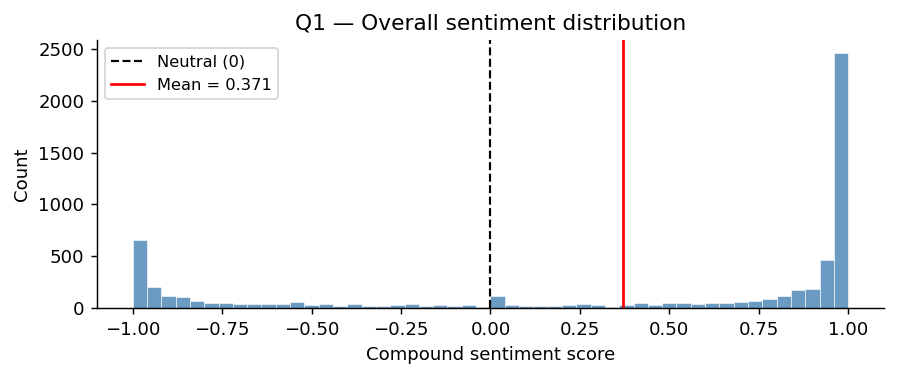

In [37]:
scores = df["sentiment_score"].dropna()
t_stat, t_p = stats.ttest_1samp(scores, 0)
w_stat, w_p = stats.wilcoxon(scores)

print("=== Q1: Is overall sentiment neutral (≈0)? ===")
print(f"  Mean ± std          : {scores.mean():.4f} ± {scores.std():.4f}")
print(f"  Median              : {scores.median():.4f}")
print(f"  t-test vs 0         : t={t_stat:.3f}  p={t_p:.4e}")
print(f"  Wilcoxon signed-rank: W={w_stat:.1f}  p={w_p:.4e}")
if t_p < 0.05:
    print("Sentiment significantly non-zero: Wikipedia is not perfectly neutral")
else:
    print("Cannot reject neutrality: mean sentiment indistinguishable from 0")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(scores, bins=50, color="steelblue", alpha=0.8, edgecolor="white", linewidth=0.4)
ax.axvline(0,             color="black", linewidth=1.2, linestyle="--", label="Neutral (0)")
ax.axvline(scores.mean(), color="red",   linewidth=1.5, linestyle="-",
           label=f"Mean = {scores.mean():.3f}")
ax.set_xlabel("Compound sentiment score")
ax.set_ylabel("Count")
ax.set_title("Q1 — Overall sentiment distribution")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("q1_neutrality.png", dpi=150, bbox_inches="tight")
plt.show()

#### __Q2 - Does Sentiment Differ By Party__

=== Q2: Sentiment by party ===
Party                n     mean    median
  Democrat        3190   0.3852    0.9081
  Republican      2716   0.3496    0.8750
  Other            232   0.4152    0.8411
Kruskal-Wallis: H=3.078  p=2.1462e-01
Pairwise Mann-Whitney (Bonferroni α=0.0167):
  Democrat vs Republican  : U=4445513  p=8.2234e-02  ✗ not significant
  Democrat vs Other       : U=371994  p=8.9302e-01  ✗ not significant
  Republican vs Other       : U=307824  p=5.6115e-01  ✗ not significant


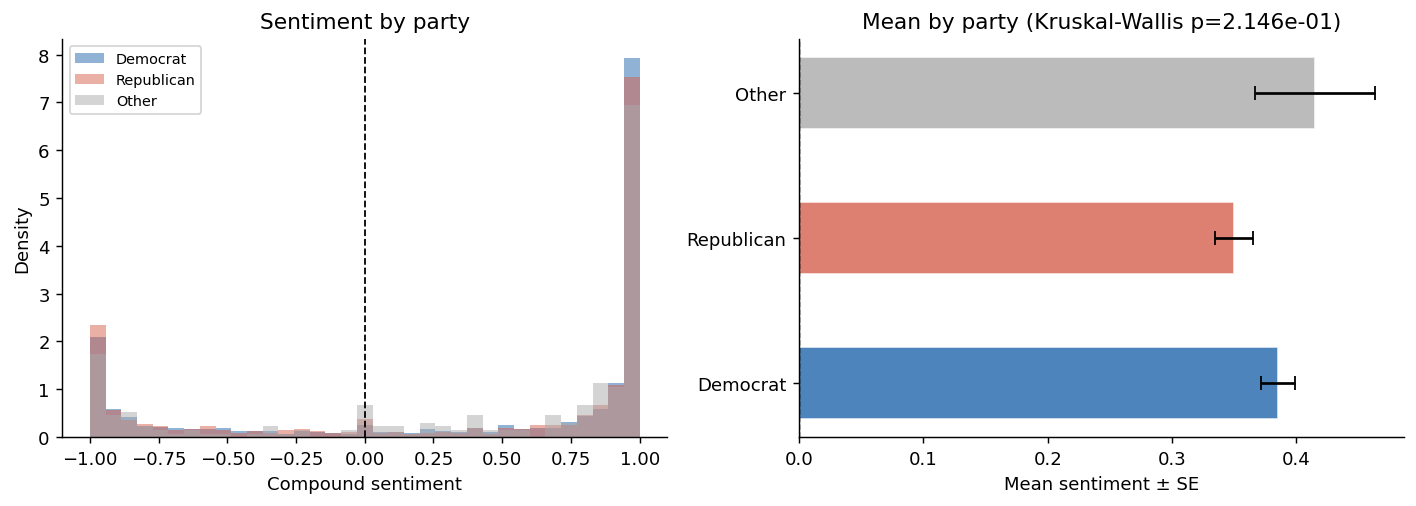

In [38]:
parties = ["Democrat", "Republican", "Other"]
groups  = [df[df["party"] == p]["sentiment_score"].dropna() for p in parties]
h_stat_party, h_p_party = stats.kruskal(*groups)

print("=== Q2: Sentiment by party ===")
print(f"{'Party':15s}  {'n':>5}  {'mean':>7}  {'median':>8}")
for p, g in zip(parties, groups):
    print(f"  {p:13s}  {len(g):5d}  {g.mean():7.4f}  {g.median():8.4f}")
print(f"Kruskal-Wallis: H={h_stat_party:.3f}  p={h_p_party:.4e}")

pairs      = [("Democrat","Republican"),("Democrat","Other"),("Republican","Other")]
alpha_bonf = 0.05 / len(pairs)
print(f"Pairwise Mann-Whitney (Bonferroni α={alpha_bonf:.4f}):")
for p1, p2 in pairs:
    g1 = df[df["party"]==p1]["sentiment_score"].dropna()
    g2 = df[df["party"]==p2]["sentiment_score"].dropna()
    u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    sig  = "✓ significant" if p < alpha_bonf else "✗ not significant"
    print(f"  {p1} vs {p2:12s}: U={u:.0f}  p={p:.4e}  {sig}")

COLORS = {"Democrat":"#2166ac","Republican":"#d6604d","Other":"#aaaaaa"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for p, g, color in zip(parties, groups, COLORS.values()):
    axes[0].hist(g, bins=35, alpha=0.5, color=color, label=p, density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Compound sentiment"); axes[0].set_ylabel("Density")
axes[0].set_title("Sentiment by party"); axes[0].legend(fontsize=8)
means = [g.mean() for g in groups]; sems = [g.sem() for g in groups]
axes[1].barh(parties, means, xerr=sems, color=list(COLORS.values()),
             alpha=0.8, edgecolor="white", height=0.5,
             error_kw=dict(ecolor="black", capsize=4))
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Mean sentiment ± SE")
axes[1].set_title(f"Mean by party (Kruskal-Wallis p={h_p_party:.3e})")
plt.tight_layout()
plt.savefig("q2_party_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

#### __Q3 - Does Sentiment Differ By Gender__

=== Q3: Sentiment by gender ===
  male      n= 4895  mean=0.3496  std=0.7953
  female    n= 1238  mean=0.4540  std=0.7513
Mann-Whitney U: U=2857094  p=1.8916e-03
Significant


/var/folders/pt/srr73kjx1pdbnpwylcyp844r0000gn/T/ipykernel_34398/4013705112.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([g_male, g_fem], labels=["male","female"], patch_artist=True,


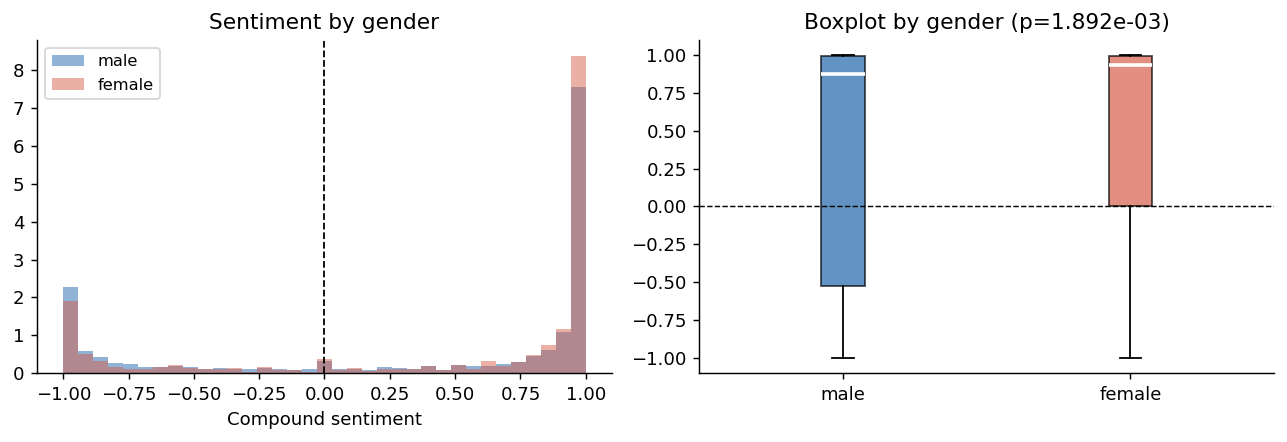

In [39]:
g_male = df[df["gender"]=="male"]["sentiment_score"].dropna()
g_fem  = df[df["gender"]=="female"]["sentiment_score"].dropna()
u_stat, u_p = stats.mannwhitneyu(g_male, g_fem, alternative="two-sided")

print("=== Q3: Sentiment by gender ===")
for label, g in zip(["male","female"], [g_male, g_fem]):
    print(f"  {label:8s}  n={len(g):5d}  mean={g.mean():.4f}  std={g.std(ddof=0):.4f}")
print(f"Mann-Whitney U: U={u_stat:.0f}  p={u_p:.4e}")
print("Significant" if u_p < 0.05 else "No significant gender difference")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for label, g, color in zip(["male","female"],[g_male,g_fem],["#2166ac","#d6604d"]):
    axes[0].hist(g, bins=35, alpha=0.5, color=color, label=label, density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Compound sentiment"); axes[0].legend(fontsize=9)
axes[0].set_title("Sentiment by gender")
axes[1].boxplot([g_male, g_fem], labels=["male","female"], patch_artist=True,
                medianprops=dict(color="white", linewidth=2))
for box, color in zip(axes[1].patches, ["#2166ac","#d6604d"]):
    box.set_facecolor(color); box.set_alpha(0.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Boxplot by gender (p={u_p:.3e})")
plt.tight_layout()
plt.savefig("q3_gender_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

#### __Q4 - Does Node Centrality Reflect Neutrality__

=== Q4: Centrality vs sentiment ===
  Spearman ρ(degree, sentiment)   = +0.343  p=4.3949e-167
  Spearman ρ(degree, |sentiment|) = +0.581  p=0.0000e+00
 Higher degree correlates with more extreme articles


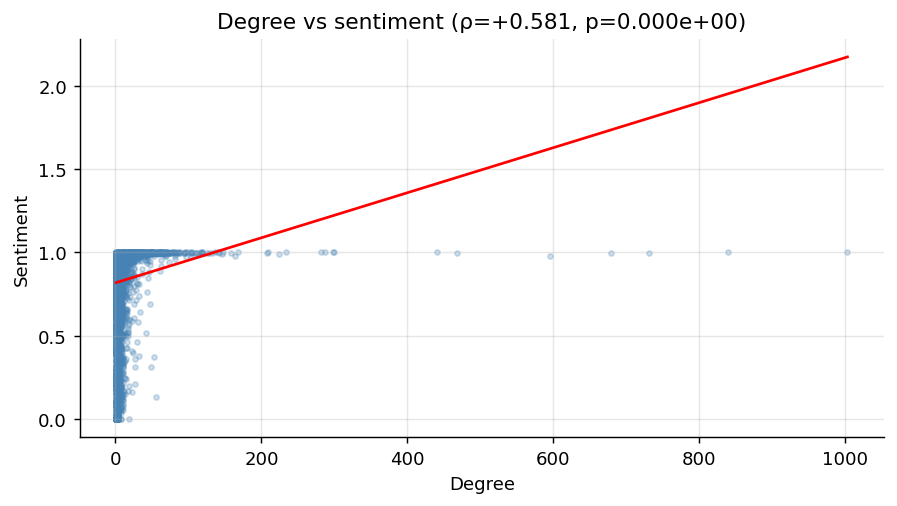

In [40]:
valid = df[df["sentiment_score"].notna() & df["degree"].notna()].copy()
r_deg, p_deg = spearmanr(valid["degree"], valid["sentiment_score"])
r_abs, p_abs = spearmanr(valid["degree"], valid["sentiment_abs"])

print("=== Q4: Centrality vs sentiment ===")
print(f"  Spearman ρ(degree, sentiment)   = {r_deg:+.3f}  p={p_deg:.4e}")
print(f"  Spearman ρ(degree, |sentiment|) = {r_abs:+.3f}  p={p_abs:.4e}")
if p_abs < 0.05:
    direction = "more neutral" if r_abs < 0 else "more extreme"
    print(f" Higher degree correlates with {direction} articles")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(valid["degree"], valid["sentiment_abs"],
           alpha=0.25, s=8, color="steelblue")
z  = np.polyfit(valid["degree"], valid["sentiment_abs"], 1)
xr = np.linspace(valid["degree"].min(), valid["degree"].max(), 100)
ax.plot(xr, np.polyval(z, xr), color="red", linewidth=1.5)
ax.set_xlabel("Degree"); ax.set_ylabel("Sentiment")
ax.set_title(f"Degree vs sentiment (ρ={r_abs:+.3f}, p={p_abs:.3e})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("q4_centrality_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

#### __Q5 - Does Sentiment Vary With Political Position__

=== Q5: Sentiment by position tier ===
  President                  n=   23  mean=0.5502  std=0.8154
  Vice President             n=   11  mean=0.9873  std=0.0225
  Cabinet Secretary          n=  271  mean=0.4749  std=0.7971
  Advisor/Staff              n=   35  mean=0.5104  std=0.8016
  US Senator                 n=  353  mean=0.6530  std=0.6976
  Other                      n= 2483  mean=0.2470  std=0.7725
  US Representative          n= 1680  mean=0.4658  std=0.7823
  Governor                   n=  245  mean=0.4166  std=0.8364
  Lieutenant Governor        n=  196  mean=0.4034  std=0.7916
  Ambassador                 n=   42  mean=0.5846  std=0.7474
  State Senator              n=   34  mean=0.4595  std=0.6575
  State Legislator           n=  352  mean=0.2880  std=0.7672
  Mayor                      n=  294  mean=0.3855  std=0.8243
  City Council               n=   33  mean=0.3698  std=0.8103
  Attorney General           n=   35  mean=0.0853  std=0.8644
  Judge                      n=

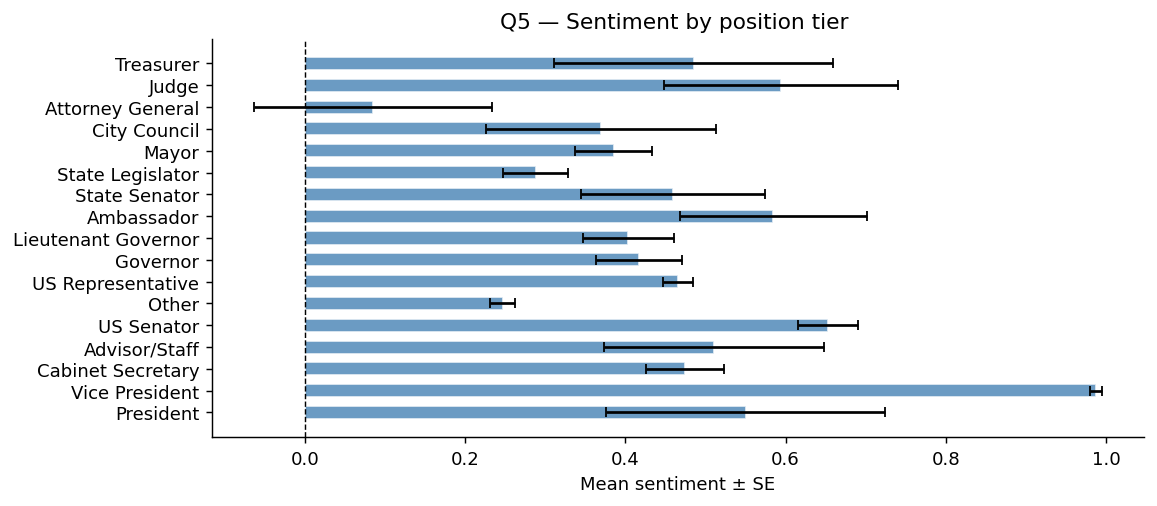

In [43]:
def simplify_position(pos):
    if pos is None:
        return "Other"

    p = pos.lower()

    # Top executive roles
    if "president of the united states" in p and "vice" not in p:
        return "President"
    if "vice president" in p:
        return "Vice President"
    if "governor" in p and "lieutenant" not in p:
        return "Governor"
    if "lieutenant governor" in p:
        return "Lieutenant Governor"
    if "mayor" in p:
        return "Mayor"

    # Federal legislature
    if "speaker of the house" in p:
        return "Speaker"
    if "united states senator" in p:
        return "US Senator"
    if "state senator" in p:
        return "State Senator"
    if "senator" in p:
        return "Senator"

    if (
        "united states representative" in p
        or "member of the united states house of representatives" in p
        or "u.s. representative" in p
        or "congressman" in p
        or "congresswoman" in p
    ):
        return "US Representative"

    # State/local legislature
    if "state representative" in p or "state assembly" in p:
        return "State Legislator"
    if "city council" in p or "councilmember" in p:
        return "City Council"

    # Cabinet / executive administration
    if "secretary" in p:
        return "Cabinet Secretary"
    if "attorney general" in p:
        return "Attorney General"
    if "treasurer" in p:
        return "Treasurer"

    # Diplomacy / judiciary
    if "ambassador" in p:
        return "Ambassador"
    if "judge" in p or "justice" in p:
        return "Judge"

    # Political party / campaign roles
    if "chairperson" in p or "party chair" in p:
        return "Party Leadership"
    if "advisor" in p or "counsel" in p or "chief of staff" in p:
        return "Advisor/Staff"

    return "Other"

df["position_simple"] = df["position"].apply(simplify_position)
tiers  = df["position_simple"].unique()
groups = [df[df["position_simple"]==t]["sentiment_score"].dropna() for t in tiers]
groups_valid = [(t, g) for t, g in zip(tiers, groups) if len(g) >= 5]

print("=== Q5: Sentiment by position tier ===")
for t, g in groups_valid:
    print(f"  {t:25s}  n={len(g):5d}  mean={g.mean():.4f}  std={g.std(ddof=0):.4f}")

labels_v = [t for t, _ in groups_valid]
means_v  = [g.mean() for _, g in groups_valid]
sems_v   = [g.sem()  for _, g in groups_valid]
fig, ax  = plt.subplots(figsize=(9, 4))
ax.barh(labels_v, means_v, xerr=sems_v, color="steelblue", alpha=0.8,
        edgecolor="white", height=0.6, error_kw=dict(ecolor="black", capsize=3))
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean sentiment ± SE")
ax.set_title(f"Q5 — Sentiment by position tier ")
plt.tight_layout()
plt.savefig("q5_position_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

#### __Results__

In [24]:
print("Summary of findings")
print()
print("Q1 Neutrality  :", "= 0 (Wikipedia not fully neutral)" if t_p < 0.05
      else "≈ 0 (Wikipedia appears neutral overall)")
print(f"               : mean={scores.mean():.4f}  p={t_p:.3e}")
print()
print("Q2 Party       :", f"significant (H={h_stat_party:.2f}, p={h_p_party:.3e})" if h_p_party < 0.05
      else f"not significant (p={h_p_party:.3e})")
print()
print("Q3 Gender      :", "significant difference" if u_p < 0.05
      else "no significant difference", f"(p={u_p:.3e})")
print()
print(f"Q4 Centrality  : ρ = {r_deg:+.3f} (p={p_deg:.3e})",
      "significant" if p_deg < 0.05 else "not significant")


=== Summary of findings ===

Q1 Neutrality  : = 0 (Wikipedia not fully neutral)
               : mean=0.3706  p=1.096e-268

Q2 Party       : not significant (p=2.146e-01)

Q3 Gender      : significant difference (p=1.892e-03)

Q4 Centrality  : ρ = +0.343 (p=4.395e-167) significant


### Overall Findings 
- Wikipedia does not offer fully neutral articles and on average represents politicians with a positive light, this can be attributed to people who write about the respective politician is generally to advocate for them.

- Wikipedia does not introduce a bias into their articles for the different political parties hence can be seen as an objective source of information.

- Across the conventional genders (Male and Female), females are associated with a more positive sentiment this could well indicate a bias in the way female politicians appear in wikipedia pages and mislead public who gain knowledge through wikipedia. However, it is important to note there are nearly 4 times more male politicians.

- Higher degree politicans tend to have more extreme articles, which can be expected as generally high degree relates to the public popularity of a politician. Hence, their policies and actions in general whether positive or negative are further reflected on by the public.

- Higher-ranking federal positions, particularly Vice Presidents, US Senators, and Presidents, tend to exhibit more positive average sentiment scores compared to local or state-level political roles. However, sentiment variability within each category remains high, suggesting that political position alone explains only a limited share of sentiment differences. Additionally, a large proportion of politicians remain grouped in the residual “Other” category, indicating that further refinement of the position classification could improve interpretability.

## 3.3 TF-IDF — distinctive vocabulary per party and per community

- Why TF-IDF over raw term frequency (down-weights ubiquitous terms like *senate*, *election*)
- The full stopword stack (auto-generated politician names + state names + Wikipedia boilerplate + cities)
- Document-level TF-IDF then group-aggregated (rather than concatenating all articles per group and computing once)
- Outputs: `tfidf_party.png`, `tfidf_communities.png`

## 3.3 TF-IDF analysis — Community interpretation through text analysis

To better understand the detected network communities, we perform a TF-IDF-based text analysis on the Wikipedia articles associated with each politician.

The purpose of this analysis is not only to identify which politicians are connected in the network, but also to investigate whether these communities share meaningful political, ideological, institutional, or historical characteristics.

This analysis is especially relevant to our research questions:

- *Do politicians cluster into communities in the network?*
- *Do these communities correspond to political ideology or party?*
- *Are central nodes more influential in the network?*

---

### Pipeline

We use the following multi-step approach:

1. **Text extraction**  
   For every politician node in the network, we collect textual content from their English Wikipedia article.

2. **Preprocessing and filtering**  
   The text is cleaned and normalized through:
   
   - lowercasing
   - tokenization
   - lemmatization
   - removal of punctuation and numbers
   - removal of generic stopwords
   - removal of politician names, state names, cities, and common Wikipedia boilerplate terms
   - filtering of short or low-information words
   - use of geonames to filter out for instance special names belonging to states and counties (fx Dakota), which are uninformative.

   This preprocessing step is important because Wikipedia articles contain a large amount of noisy and repetitive vocabulary that would otherwise dominate the analysis.

3. **Community aggregation**  
   After performing Louvain community detection on the politician network, the articles belonging to politicians inside the same community are grouped together for analysis.

4. **TF-IDF computation**  
   We compute TF-IDF (Term Frequency–Inverse Document Frequency) scores to identify words that are particularly distinctive for a given party or community.

   - **TF (Term Frequency)** measures how often a term appears within a document or group.
   - **IDF (Inverse Document Frequency)** downweights words that appear frequently across many groups.

---

### Why TF-IDF instead of raw term frequency?

We use TF-IDF rather than raw word frequency because many political terms appear universally across nearly all politician articles.

Examples include:

- *senate*
- *election*
- *american*
- *state*
- *president*

Using raw frequency alone would therefore produce highly generic and less informative word clouds.

TF-IDF instead highlights vocabulary that is more characteristic of a specific community or political grouping.

---

### Word cloud visualization

The highest TF-IDF scoring words are visualized using word clouds for:

- political parties
- detected louvain communities

The size of each word reflects its relative TF-IDF importance within the corresponding group.

In addition to community-based TF-IDF analysis, we also generate TF-IDF word clouds based on political party labels (e.g. Democrat and Republican).

Unlike the Louvain communities, which are discovered purely from the network structure, party groupings are predefined metadata labels. This allows us to compare whether organically detected network communities correspond to known political party structures or ideological divisions.

This allows us to investigate whether the detected communities appear to reflect:

- shared political ideology
- institutional roles
- historical periods
- geographic affiliations
- party structures
- or other common themes


In [61]:
import ast, re
from wordcloud import WordCloud

plt.rcParams.update({"figure.dpi": 120})

text_df = pd.read_csv("tokenized_wikipage2.csv")

def safe_parse(val):
    if not isinstance(val, str): return []
    try:    return ast.literal_eval(val)
    except: return val.split()

text_df["tokens_parsed"] = text_df["tokens_lemmatized"].apply(safe_parse)

In [62]:
# ── Auto-generate name stopwords from the dataset ─────────────────────────────
name_stopwords = set()
for name in text_df["name"].dropna():
    parts = re.sub(r"[^a-zA-Z ]", "", name.lower()).split()
    name_stopwords.update(parts)
print(f"Name-derived stopwords: {len(name_stopwords)}")

# ── Geographic terms that dominate geo-heavy communities ──────────────────────
GEO_STOPWORDS = {
    "california", "los", "angeles", "san", "francisco", "diego",
    "jose", "sacramento", "fresno", "riverside", "oakland",
    "york", "manhattan", "brooklyn", "bronx", "queens", "albany",
    "buffalo", "harlem", "staten", "island",
    "jersey", "newark", "camden", "bergen", "essex", "passaic",
    "hunterdon", "rutgers",
    "alaska", "hawaii", "anchorage", "fairbanks", "honolulu",
    "albuquerque", "pacific", "hawaiian", "alaskan",
    "city", "county", "township", "borough",
    "municipality", "region", "area", "neighborhood",
    "north", "south", "east", "west", "central",
}

# ── Wikipedia boilerplate + generic political terms ───────────────────────────
BOILERPLATE = {
    "born", "die", "death", "age", "old", "year", "serve", "serving",
    "served", "also", "one", "two", "three", "first", "second", "third",
    "new", "later", "early", "late", "since", "become", "include",
    "many", "well", "make", "take", "give", "come", "go", "know",
    "time", "way", "part", "day", "use", "say", "would", "could",
    "th", "u", "s", "d", "r", "man", "woman",
    "american", "united", "state", "states", "federal",
    "political", "politician", "politics",
    "member", "congress", "congressional",
    "representative", "senator", "president", "vice",
    "democrat", "republican", "democratic", "party",
    "election", "elect", "elected", "reelect",
    "office", "term", "campaign", "vote", "voting",
    "government", "administration", "official",
    "house", "senate", "committee", "bill", "law",
    "national", "public", "support", "oppose",
    "position", "issue", "school", "university",
    "work", "primary", "general", "local", "special",
    "district", "mayor", "governor", "assembly", "council", "attorney",
    "delegate", "secretary", "treasurer", "commissioner", "legislature",
    "legislative", "executive", "judicial", "statehouse", "capitol",
    "subcommittee", "speaker", "chairman", "chairwoman", "chairperson",
    "leader", "leaders", "caucus", "kansa", "lieutenant", "court",
    "alabama", "arizona", "arkansas", "colorado", "connecticut",
    "delaware", "florida", "georgia", "idaho", "illinois", "indiana",
    "iowa", "kansas", "kentucky", "louisiana", "maine", "maryland",
    "massachusetts", "michigan", "minnesota", "mississippi", "missouri",
    "montana", "nebraska", "nevada", "hampshire", "mexico", "carolina",
    "dakota", "ohio", "oklahoma", "oregon", "pennsylvania", "rhode",
    "tennessee", "texas", "utah", "vermont", "virginia", "washington",
    "wisconsin", "wyoming", "chicago", "cincinnati", "columbus", "cleveland",
    "detroit", "miami", "atlanta", "boston", "memphis", "nashville",
    "knoxville", "louisville", "lexington", "richmond", "norfolk",
    "portland", "salem", "eugene", "houston", "dallas", "austin",
    "antonio", "el", "paso",
}

STOPWORDS = name_stopwords | GEO_STOPWORDS | BOILERPLATE
print(f"Total stopwords: {len(STOPWORDS)}")

# ── Filter tokens ──────────────────────────────────────────────────────────────
def filter_tokens(token_list):
    return [
        t for t in token_list
        if len(t) >= 3
        and not t.isdigit()
        and not re.match(r'^\d', t)
        and t not in STOPWORDS
        and re.match(r'^[a-z]', t)
    ]

text_df["tokens_filtered"] = text_df["tokens_parsed"].apply(filter_tokens)
text_df["doc_len"]         = text_df["tokens_filtered"].str.len()

df_valid = text_df[text_df["doc_len"] >= 30].copy().reset_index(drop=True)
print(f"Valid documents : {len(df_valid)}")
print(f"Mean doc length : {df_valid['doc_len'].mean():.0f} tokens")
print(f"Median          : {df_valid['doc_len'].median():.0f} tokens")

sample = df_valid[df_valid["doc_len"] > 100].iloc[0]
print(f"\nSample ({sample['name']}): {sample['tokens_filtered'][:20]}")

Name-derived stopwords: 5314
Total stopwords: 5530
Valid documents : 5715
Mean doc length : 498 tokens
Median          : 256 tokens

Sample (Stephen Miller): ['advisor', 'deputy', 'chief', 'staff', 'policy', 'homeland', 'security', 'advisor', 'senior', 'advisor', 'director', 'speechwriting', 'considered', 'influential', 'figure', 'trumpism', 'movement', 'describe', 'farright', 'antiimmigration']


## 2 — TF-IDF

**TF** is computed per individual document:
$$TF(t, d) = \log\left(1 + \frac{\text{count}(t, d)}{|d|}\right)$$

**IDF** is computed across all individual articles (not communities):
$$IDF(t) = \log\left(\frac{N}{df(t)}\right)$$

This ensures verbs like "policy" that appear in thousands of articles get near-zero IDF,
while distinctive policy terms that appear in only a subset get high IDF.

In [63]:

def compute_tf(token_list):
    n      = len(token_list)
    counts = Counter(token_list)
    return {term: np.log(1 + count / n) for term, count in counts.items()}

print("Computing TF for all documents...")
tf_per_doc = [compute_tf(tokens) for tokens in df_valid["tokens_filtered"]]
print(f"  Done — {len(tf_per_doc)} documents")

# ── Step 2: Document frequency across all articles ────────────────────────────
print("Computing document frequencies...")
N        = len(df_valid)
doc_freq = defaultdict(int)

for token_list in df_valid["tokens_filtered"]:
    for term in set(token_list):    # set() — count each term once per doc
        doc_freq[term] += 1

# Apply min/max DF filter to remove very rare and very common terms
MIN_DF = 10            # must appear in at least 10 articles
MAX_DF = int(0.45 * N) # must appear in at most 45% of articles

print(f"  Total unique terms before filter : {len(doc_freq):,}")
doc_freq_filtered = {
    term: count for term, count in doc_freq.items()
    if MIN_DF <= count <= MAX_DF
}
print(f"  Vocabulary after DF filter       : {len(doc_freq_filtered):,}")

# ── Step 3: IDF ───────────────────────────────────────────────────────────────
idf_dict = {
    term: np.log(N / count)
    for term, count in doc_freq_filtered.items()
}

# ── Step 4: TF-IDF per document ───────────────────────────────────────────────
print("Computing TF-IDF per document...")
tfidf_per_doc = [
    {term: tf * idf_dict[term]
     for term, tf in doc_tf.items()
     if term in idf_dict}
    for doc_tf in tf_per_doc
]
print("  Done")


Computing TF for all documents...
  Done — 5715 documents
Computing document frequencies...
  Total unique terms before filter : 82,526
  Vocabulary after DF filter       : 11,727
Computing TF-IDF per document...
  Done


## 3 — Group aggregation

In [64]:
def group_tfidf(df_subset, top_n=80):
    """
    Average TF-IDF across all documents in df_subset.
    Returns top_n {term: avg_score} dict.
    """
    indices = df_valid.index.get_indexer(df_subset.index)
    indices = indices[indices >= 0]
    if len(indices) == 0:
        return {}

    agg = defaultdict(float)
    for i in indices:
        for term, score in tfidf_per_doc[i].items():
            agg[term] += score

    n   = len(indices)
    avg = {term: total / n for term, total in agg.items()}
    return dict(sorted(avg.items(), key=lambda x: x[1], reverse=True)[:top_n])

## 4 — Party word clouds


Democrat top 10 terms:
  guam                            0.00275
  health                          0.00272
  chair                           0.00263
  award                           0.00249
  director                        0.00242
  community                       0.00236
  degree                          0.00236
  appoint                         0.00234
  practice                        0.00232
  war                             0.00231

Republican top 10 terms:
  tax                             0.00299
  percent                         0.00292
  nominee                         0.00272
  conservative                    0.00268
  unopposed                       0.00266
  army                            0.00242
  appoint                         0.00238
  company                         0.00234
  nomination                      0.00233
  race                            0.00232


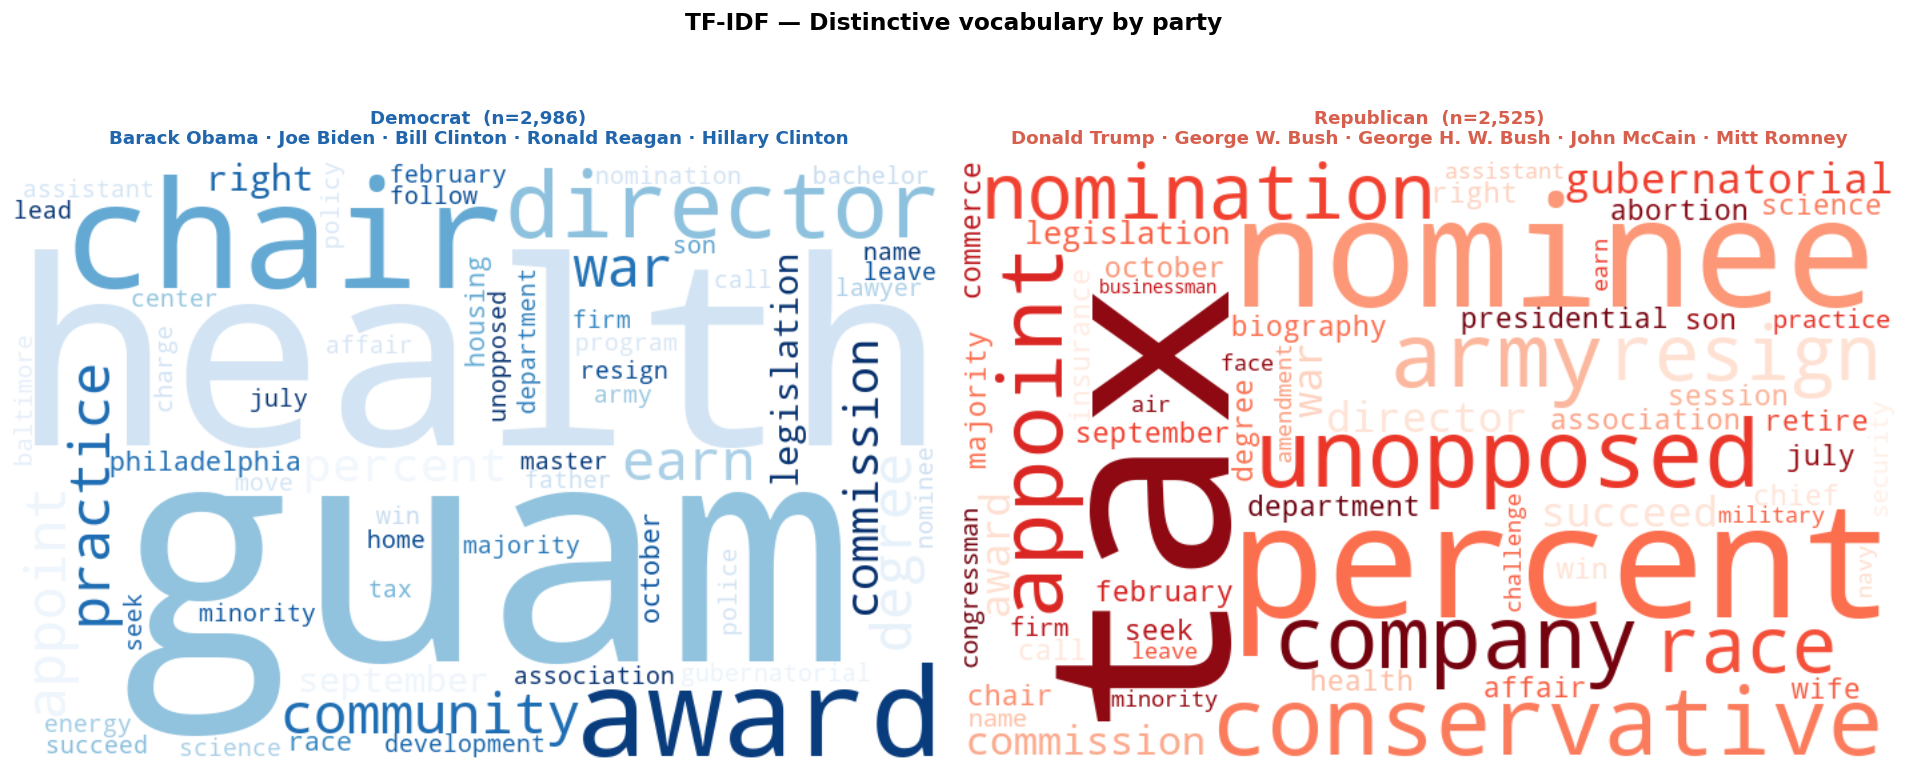

Saved → tfidf_party.png


In [65]:
PARTY_COLORS = {"Democrat": "#2166ac", "Republican": "#d6604d"}

party_terms = {}
for party in ["Democrat", "Republican"]:
    subset              = df_valid[df_valid["party"] == party]
    party_terms[party]  = group_tfidf(subset)

    print(f"\n{party} top 10 terms:")
    for term, score in list(party_terms[party].items())[:10]:
        print(f"  {term:30s}  {score:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (party, terms) in zip(axes, party_terms.items()):
    cmap = "Blues" if party == "Democrat" else "Reds"
    n    = len(df_valid[df_valid["party"] == party])

    top5 = (df_valid[df_valid["party"] == party]
            .dropna(subset=["degree"])
            .nlargest(5, "degree")["name"].tolist())

    wc = WordCloud(
        width=700, height=450, background_color="white",
        colormap=cmap, max_words=60,
        prefer_horizontal=0.85, min_font_size=9, collocations=False,
    ).generate_from_frequencies(terms)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(
        f"{party}  (n={n:,})\n" + " · ".join(top5),
        fontsize=11, fontweight="bold", pad=10,
        color=PARTY_COLORS[party]
    )
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary by party",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_party.png")


## 5 — Community word clouds

Computing community TF-IDF...
  Community  15 (n= 777): ['war', 'army', 'percent', 'presidential', 'world']
  Community   2 (n= 646): ['unopposed', 'nominee', 'salt', 'charleston', 'nomination']
  Community   5 (n= 615): ['unopposed', 'runoff', 'percent', 'nominee', 'session']
  Community  30 (n= 353): ['supervisor', 'orange', 'valley', 'assemblyman', 'irvine']
  Community   6 (n= 254): ['queen', 'comptroller', 'erie', 'sit', 'nassau']
  Community   7 (n= 242): ['freeholder', 'assemblyman', 'seton', 'trenton', 'chosen']
  Community  22 (n= 237): ['lyon', 'alderman', 'peoria', 'committeeman', 'comptroller']
  Community  19 (n= 174): ['maui', 'gubernatorial', 'juneau', 'oil', 'hilo']
  Community  16 (n= 172): ['cuyahoga', 'toledo', 'minority', 'limit', 'resign']


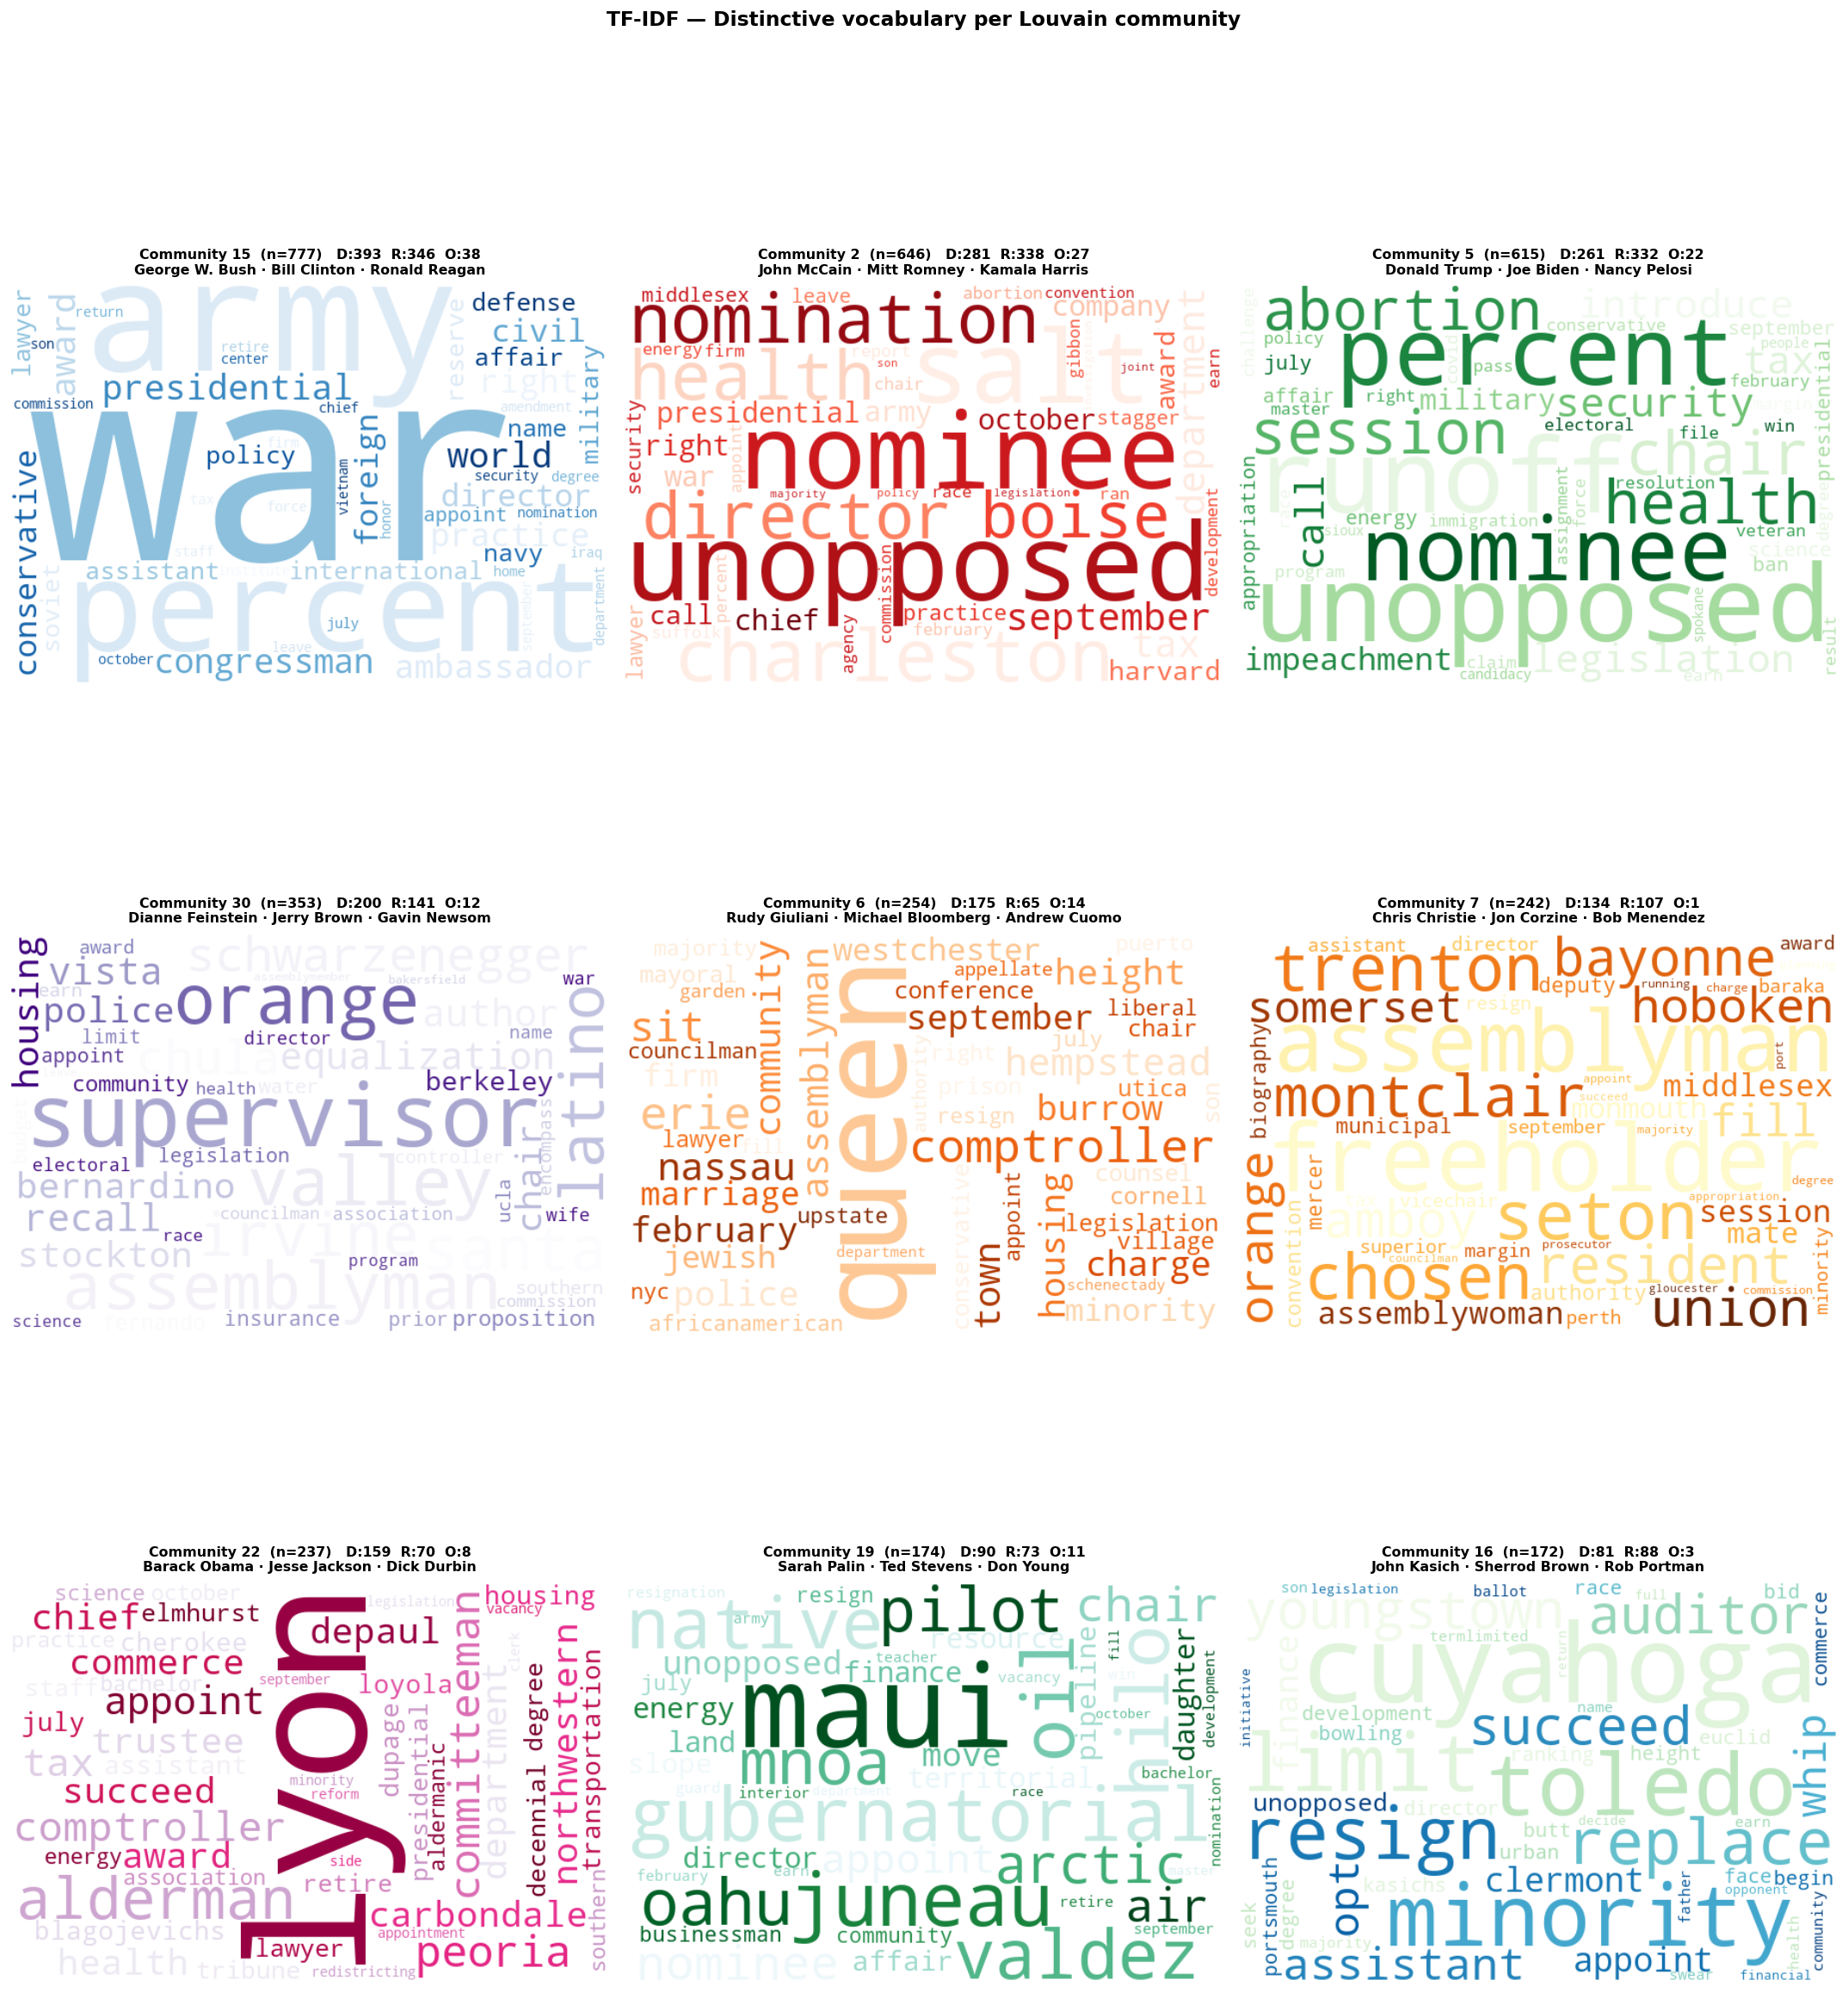

Saved → tfidf_communities.png


In [66]:
community_sizes = df_valid["community"].value_counts()
top_communities = community_sizes[community_sizes >= 50].head(9).index.tolist()

print("Computing community TF-IDF...")
comm_terms = {}
for cid in top_communities:
    subset        = df_valid[df_valid["community"] == cid]
    comm_terms[cid] = group_tfidf(subset)
    top5          = list(comm_terms[cid].keys())[:5]
    print(f"  Community {int(cid):3d} (n={int(community_sizes[cid]):4d}): {top5}")

CMAPS = ["Blues","Reds","Greens","Purples","Oranges",
         "YlOrBr","PuRd","BuGn","GnBu"]

n_cols = 3
n_rows = (len(top_communities) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, 7 * n_rows), facecolor="white")
axes_flat = list(axes.flat)

for ax, cid, cmap in zip(axes_flat, top_communities, CMAPS):
    terms = comm_terms[cid]
    if not terms:
        ax.axis("off")
        continue

    wc = WordCloud(
        width=600, height=400, background_color="white",
        colormap=cmap, max_words=50,
        prefer_horizontal=0.85, min_font_size=9, collocations=False,
    ).generate_from_frequencies(terms)
    ax.imshow(wc, interpolation="bilinear")

    n          = int(community_sizes[cid])
    party_comp = df_valid[df_valid["community"] == cid]["party"].value_counts()
    d = party_comp.get("Democrat",   0)
    r = party_comp.get("Republican", 0)
    o = party_comp.get("Other",      0)

    top3_names = (df_valid[df_valid["community"] == cid]
                  .dropna(subset=["degree"])
                  .nlargest(3, "degree")["name"].tolist())

    ax.set_title(
        f"Community {int(cid)}  (n={n})   D:{d}  R:{r}  O:{o}\n"
        + " · ".join(top3_names),
        fontsize=9.5, fontweight="bold", pad=8,
    )
    ax.axis("off")

for ax in axes_flat[len(top_communities):]:
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary per Louvain community",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_communities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_communities.png")


In [50]:
community_sizes = df_valid["community"].value_counts()
top_communities = community_sizes[community_sizes >= 50].head(9).index.tolist()

comm_token_pools = {
    cid: df_valid[df_valid["community"]==cid]["tokens_filtered"].explode().tolist()
    for cid in top_communities
}
comm_idf   = compute_idf_smoothed(list(comm_token_pools.values()), len(top_communities))
comm_terms = {}
print("Computing community TF-IDF...")
for cid in top_communities:
    comm_terms[cid] = group_tfidf_pooled(comm_token_pools[cid], comm_idf)
    top5 = list(comm_terms[cid].keys())[:5]
    print(f"  Community {int(cid):3d} (n={int(community_sizes[cid]):4d}): {top5}")

NameError: name 'compute_idf_smoothed' is not defined

In [ ]:
n_cols = 3
n_rows = (len(top_communities) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 7*n_rows), facecolor="white")
axes_flat = list(axes.flat)

for ax, cid in zip(axes_flat, top_communities):
    terms = comm_terms[cid]
    if not terms: ax.axis("off"); continue
    wc = WordCloud(
        width=800, height=400, background_color="white",
        colormap="plasma", contour_width=1, contour_color="black",
        max_words=200, prefer_horizontal=0.85, min_font_size=9, collocations=False,
    ).generate_from_frequencies(terms)
    ax.imshow(wc, interpolation="bilinear")
    n          = int(community_sizes[cid])
    party_comp = df_valid[df_valid["community"]==cid]["party"].value_counts()
    d = party_comp.get("Democrat",0); r = party_comp.get("Republican",0)
    o = party_comp.get("Other",0)
    top3_names = (df_valid[df_valid["community"]==cid]
                  .dropna(subset=["degree"]).nlargest(3,"degree")["name"].tolist())
    top_word = list(comm_terms[cid].keys())[0].replace("_"," ").title()
    ax.set_title(
        f'Community {int(cid)} — "{top_word}"  (n={n})\n'
        f"D:{d}  R:{r}  O:{o}   ·   " + " · ".join(top3_names),
        fontsize=9.5, fontweight="bold", pad=8)
    ax.axis("off")
for ax in axes_flat[len(top_communities):]: ax.axis("off")
plt.suptitle("TF-IDF — Distinctive vocabulary per Louvain community",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_communities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_communities.png")

### Interpretation of communities

The TF-IDF analysis allows us to move beyond purely structural network analysis and instead interpret what the detected communities may actually represent politically, historically, or geographically.

Rather than viewing communities simply as clusters of connected politicians, the TF-IDF vocabulary combined with the most central politicians in each community provides insight into the types of political relationships captured by the Wikipedia network.

Several communities appear highly interpretable and correspond to recognizable political ecosystems, historical periods, or regional structures.

---

#### Community 15 — “Cold War / national presidential politics”

Central politicians:
- Ronald Reagan
- George H. W. Bush
- Bill Clinton

The TF-IDF words include:

- *war*
- *army*
- *presidential*
- *world*

This community appears strongly connected to late-Cold-War and post-Cold-War presidential politics.

All three politicians dominated American national politics during the late 1980s and early 1990s and were heavily associated with:

- foreign policy
- military power
- national security
- international diplomacy
- the Soviet Union and post-Cold-War geopolitics

The vocabulary suggests that the network captures not only party structures, but also historical and geopolitical eras. The shared references between these politicians likely arise from overlapping discussions of military policy, global leadership, and international conflicts during a historically important period in American politics.

---

#### Community 2 — “National electoral / Senate / institutional politics”

Central politicians:
- Mitt Romney
- Kamala Harris
- John McCain

The TF-IDF vocabulary includes:

- *court*
- *nominee*
- *health*
- *president*
- *security*

This community appears centered around modern national institutional politics, particularly:

- Senate politics
- presidential campaigns
- Supreme Court nominations
- national policy debates

The presence of terms such as *court* and *nominee* suggests strong connections to judicial appointments and confirmation processes, while *health* likely reflects healthcare debates in modern American politics.

All three politicians were nationally significant political figures with major presidential or vice-presidential campaigns and strong Senate influence. Interestingly, the community includes both Democrats and Republicans, suggesting that the network structure captures institutional proximity and national political relevance rather than strict partisan separation alone.

---

#### Community 5 — “Modern polarized federal politics”

Central politicians:
- Donald Trump
- Joe Biden
- Nancy Pelosi

The TF-IDF words are highly conflict-oriented and legislative:

- *opposed*
- *nominee*
- *session*
- *legislation*
- *abortion*

This community appears to represent contemporary polarized federal politics and modern partisan conflict within Congress and presidential politics.

The vocabulary strongly reflects:

- legislative disputes
- political opposition
- impeachment-era rhetoric
- judicial nominations
- modern culture-war debates

The fact that Trump, Biden, and Pelosi cluster together suggests that Wikipedia links heavily encode political conflict and interaction, not merely political agreement. This community therefore appears to capture the highly interconnected nature of contemporary American national politics.

---

#### Community 30 — “California politics”

Central politicians:
- Dianne Feinstein
- Jerry Brown
- Gavin Newsom

The TF-IDF words include numerous California-specific locations and local political terminology:

- *Orange*
- *Irvine*
- *Stockton*
- *Valley*
- *assemblyman*

This community appears strongly tied to California state politics and regional governance structures.

All three politicians are highly influential California political figures connected through:

- gubernatorial politics
- San Francisco politics
- statewide Democratic networks
- California legislative structures

The vocabulary suggests that Wikipedia links strongly reflect shared regional political ecosystems and state-level institutional structures.

---

#### Community 6 — “New York politics”

Central politicians:
- Rudy Giuliani
- Michael Bloomberg
- Andrew Cuomo

The TF-IDF vocabulary includes highly New York-specific terminology:

- *Queens*
- *Nassau*
- *borough*
- *comptroller*

This community appears centered around New York City and New York State political structures.

The politicians are strongly connected through:

- mayoral politics
- gubernatorial politics
- New York institutional networks
- urban governance

The community demonstrates how geographic and municipal political structures emerge naturally from the network.

---

#### Community 7 — “New Jersey politics”

Central politicians:
- Chris Christie
- Jon Corzine
- Bob Menendez

The TF-IDF terms are heavily geographically concentrated:

- *Hoboken*
- *Bayonne*
- *Mercer*
- *Somerset*

This suggests that the community represents New Jersey political networks and state-level political relationships.

All three politicians are major New Jersey political figures associated with:

- governorships
- Senate politics
- state-level governance

The community illustrates how regional political ecosystems become highly interconnected through Wikipedia references.

---

#### Community 22 — “Chicago / Illinois Democratic politics”

Central politicians:
- Barack Obama
- Jesse Jackson
- Dick Durbin

The TF-IDF vocabulary includes:

- *alderman*
- *Illinois*
- *Chicago*

The word *alderman* is particularly associated with Chicago municipal politics, strongly suggesting that this community reflects Chicago and Illinois Democratic political structures.

The community appears tied to:

- Illinois Democratic establishment politics
- civil rights networks
- Chicago political institutions
- urban Democratic organizing

The presence of Obama, Durbin, and Jesse Jackson suggests a combination of national Democratic influence and historically important Chicago political networks.

---

#### Community 19 — “Alaska / energy politics”

Central politicians:
- Sarah Palin
- Ted Stevens
- Don Young

The TF-IDF words are highly distinctive:

- *oil*
- *pipeline*
- *arctic*

This community appears strongly connected to Alaska politics and energy policy.

All three politicians are heavily associated with:

- Alaska state politics
- oil and energy industries
- Arctic policy
- Republican northern-state politics

The vocabulary suggests that the network captures economic and regional policy specialization in addition to ideology.

---

#### Community 16 — “Ohio politics”

Central politicians:
- John Kasich
- Sherrod Brown
- Rob Portman

The TF-IDF vocabulary includes Ohio-specific locations such as:

- *Cuyahoga*
- *Youngstown*
- *Toledo*

This community appears centered around Ohio political networks and state-level governance.

The politicians are connected through:

- Senate politics
- gubernatorial politics
- Ohio institutional structures
- regional political relationships

The geographic specificity of the vocabulary strongly suggests that regional affiliation is an important driver of network connectivity.

---

Overall, the TF-IDF analysis suggests that the detected Louvain communities are not random clusters. Instead, many communities appear to correspond to meaningful political structures such as:

- geographic regions
- state-level political systems
- historical eras
- institutional roles
- legislative structures
- energy and economic policy environments
- national political conflict

Importantly, the communities do not correspond exclusively to party divisions. Instead, the analysis suggests that Wikipedia link structures encode multiple overlapping forms of political similarity, including geography, institutions, history, governance structures, and national political relevance.

This supports the idea that politicians do cluster into meaningful communities in the network, but that these communities reflect more than simple partisan identity alone.

# 4 — Discussion

## What went well?

_..._

## What is still missing? What could be improved? Why?

_..._

### Known limitations

**VADER on long text:** VADER was tuned for social media posts of 1–3 sentences. On Wikipedia articles of several thousand words, the compound score averages over a very long text and converges toward zero for almost all articles. This makes it hard to detect genuine editorial bias; a model fine-tuned on encyclopaedia text would be more sensitive.

**POS tagging and proper nouns:** Even with original-case tagging, some city and person names slip through as common nouns (e.g. lowercasing before the tagger sees them, or ambiguous names like "Lincoln" that are both a surname and a common noun). The `geonamescache` blocklist partially addresses this for geographic names but not for person names that happen to be dictionary words.

**Power law fit:** The log-log linear regression fit is a simple estimator of $\gamma$. A more rigorous approach would use maximum likelihood estimation (MLE) with a goodness-of-fit test (Clauset et al. 2009) to verify that a power law is genuinely the best-fitting model and not merely an approximate one.

**Temporal dynamics:** Our dataset is a static snapshot. Politicians active in 2020 and politicians active in 1985 are treated identically, even though their Wikipedia article quality and link density differ systematically (older politicians have had more time for editors to add cross-references).